# 7COM1079 Coursework 2 - Generative Adversarial Networks (Set 4)

This notebook is my submission for the GAN coursework. It follows the two parts in the brief: Part 1 builds GANs from scratch on simple 2D data, and Part 2 applies GANs to three real datasets from medicine, cybersecurity and creative art.

I use two frameworks on purpose, to show I can work in both. Part 1 and the two image problems are written in PyTorch; the tabular traffic model in Part 2.2 is written in TensorFlow/Keras. The table maps each part to its framework and the main design choice I made for it.

| Part | Task | Framework | Implementation style |
|------|------|-----------|----------------------|
| 1 | GANs from scratch on 2D data (sine, spiral, architecture study) | PyTorch | configurable MLPs driven by a `Toy2DGAN` trainer class |
| 2.1 | OCTMNIST medical DCGAN + conditional GAN | PyTorch | transposed-conv DCGAN, optional `DataParallel` |
| 2.2 | CICIDS 2017 tabular GAN + full-day extension | TensorFlow/Keras | `keras.Model` subclass with a custom `train_step` |
| 2.3 | QuickDraw sketch DCGAN + extra categories | PyTorch | transposed-conv DCGAN fed by a custom `Dataset` |

Seeds are fixed up front (`TORCH_SEED = 3030` for PyTorch/NumPy and `KERAS_SEED = 4040` for TensorFlow) so the figures reproduce. Every figure is written to `set4_results/` and zipped at the end.

**Before running:** OCTMNIST downloads through `medmnist` and the QuickDraw bitmaps download from Google Cloud Storage. For CICIDS 2017, put the eight daily CSVs in one folder and set `CICIDS_FOLDER` in Part 2.2. A GPU and internet access should be enabled.

> The outputs are cleared in this copy - run the cells top to bottom on a GPU runtime to regenerate every figure and metric. The reflection cells use `[ ... ]` markers where a value from your own run should be filled in.

## Environment setup (run this first)

This installs the packages the notebook needs that may not already be on the runtime. The Torch stack is installed first so nothing after it pulls a mismatched build over the top. Re-running is safe - pip skips anything already present. If TensorFlow does not see the GPU straight after installing, restart the kernel once.

In [1]:
import sys
import subprocess


def pip_install(*names):
    """Install packages into the running kernel; quiet and non-fatal."""
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *names], check=False)


# Torch stack first so the later installs never replace it with a different build.
pip_install("torch", "torchvision")
pip_install("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist")
pip_install("tensorflow[and-cuda]")   # drop "[and-cuda]" on a CPU-only machine
print("Dependencies ready.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


Dependencies ready.


## Part 1 - Building and understanding GANs from scratch (PyTorch)

Part 1 is written from scratch in PyTorch. The generator and critic are small MLPs, and training uses the non-saturating GAN loss (`BCEWithLogitsLoss`). I kept the networks configurable - depth and activation are just constructor arguments - and wrapped the training loop in a `Toy2DGAN` class, so the same code drives all three tasks: the sine wave, the spiral and the architecture comparison.

In [2]:
import os
import math
import random

import numpy as np
import scipy.linalg
import torch
from torch import nn
import matplotlib.pyplot as plt

# These base imports (os / numpy / scipy / torch / matplotlib) are made once here and
# reused by the TensorFlow sections later on, since Part 1 always runs first.

TORCH_SEED = 3030          # drives every PyTorch / NumPy result in the notebook
KERAS_SEED = 4040          # drives the TensorFlow section (Part 2.2)
OUTPUT_DIR = "set4_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def fix_torch_seeds(seed=TORCH_SEED):
    """Pin the Python, NumPy and PyTorch RNGs so results reproduce between runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


fix_torch_seeds()
COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} on {COMPUTE_DEVICE}; figures -> {OUTPUT_DIR}/")


def save_figure(fig, filename):
    """Write a Matplotlib figure into OUTPUT_DIR at a consistent resolution."""
    fig.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches="tight")


def draw_point_clouds(real_xy, fake_xy, heading, filename=None):
    """Scatter real and generated 2D samples on one set of axes."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(real_xy[:, 0], real_xy[:, 1], s=6, alpha=0.4, color="#2f6f9f", label="Real")
    ax.scatter(fake_xy[:, 0], fake_xy[:, 1], s=6, alpha=0.4, color="#d9622b", label="Generated")
    ax.set_title(heading); ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="datalim"); ax.legend(); ax.grid(alpha=0.2)
    if filename:
        save_figure(fig, filename)
    plt.show()


def draw_loss_curves(disc_losses, gen_losses, heading, filename=None):
    """Plot discriminator and generator loss traces together."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(disc_losses, color="#2f6f9f", alpha=0.85, label="Discriminator")
    ax.plot(gen_losses, color="#d9622b", alpha=0.85, label="Generator")
    ax.set_title(heading); ax.set_xlabel("step"); ax.set_ylabel("BCE loss")
    ax.legend(); ax.grid(alpha=0.2)
    if filename:
        save_figure(fig, filename)
    plt.show()

PyTorch 2.10.0+cu128 on cuda; figures -> set4_results/


### 1.1 - Target distributions and the configurable GAN

This cell sets the Part 1 hyperparameters and defines the two target samplers (the sine wave and the spiral). Keeping the settings in one block makes it clear what changes between tasks and what stays the same.

In [3]:
LATENT_2D = 24                 # noise width for the toy 2D generators
HIDDEN_2D = 192
BASE_DEPTH = 3                 # baseline generator depth (Tasks 1 and 2)
MOD_DEPTH = 5                  # deeper variant used in the Task 3 comparison
GEN_ACT = "gelu"               # baseline generator activation
MOD_ACT = "leaky_relu_0.3"     # activation swapped in for the Task 3 variant


def sample_sine(n_points, low=-math.pi, high=math.pi):
    """Draw n points from y = sin(x) on [low, high]; returns an (n, 2) tensor."""
    xs = torch.empty(n_points, 1).uniform_(low, high)
    return torch.cat([xs, torch.sin(xs)], dim=1)


def sample_spiral(n_points, revolutions=2.5, jitter=0.02):
    """Draw n points from an Archimedean spiral with a little radial noise."""
    angle = torch.rand(n_points, 1) * (revolutions * 2 * math.pi)
    radius = angle / (revolutions * 2 * math.pi) + torch.randn(n_points, 1) * jitter
    return torch.cat([radius * torch.cos(angle), radius * torch.sin(angle)], dim=1)


def activation_layer(tag):
    """Map a short string tag to a fresh activation module."""
    options = {
        "relu": lambda: nn.ReLU(),
        "gelu": lambda: nn.GELU(),
        "tanh": lambda: nn.Tanh(),
        "leaky_relu_0.2": lambda: nn.LeakyReLU(0.2),
        "leaky_relu_0.3": lambda: nn.LeakyReLU(0.3),
    }
    if tag not in options:
        raise KeyError(f"unsupported activation tag: {tag}")
    return options[tag]()

The model classes and the trainer come next. The generator applies LayerNorm after each linear layer, and the `Toy2DGAN` trainer adds a small amount of noise to the critic's inputs that decays to zero over training. That noise is a simple stabiliser: it stops the critic separating the real and fake clouds too early, which is a common cause of vanishing generator gradients on toy problems like these.

In [4]:
class ToyGenerator(nn.Module):
    """Small MLP mapping a latent vector to a 2D coordinate."""

    def __init__(self, latent=LATENT_2D, hidden=HIDDEN_2D, depth=BASE_DEPTH, act=GEN_ACT):
        super().__init__()
        blocks, in_dim = [], latent
        for _ in range(depth):
            blocks += [nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), activation_layer(act)]
            in_dim = hidden
        blocks.append(nn.Linear(in_dim, 2))
        self.body = nn.Sequential(*blocks)

    def forward(self, z):
        return self.body(z)


class ToyCritic(nn.Module):
    """Small MLP scoring a 2D point as real (high) or fake (low)."""

    def __init__(self, hidden=HIDDEN_2D, depth=BASE_DEPTH, act="leaky_relu_0.2"):
        super().__init__()
        blocks, in_dim = [], 2
        for _ in range(depth):
            blocks += [nn.Linear(in_dim, hidden), activation_layer(act), nn.Dropout(0.2)]
            in_dim = hidden
        blocks.append(nn.Linear(in_dim, 1))
        self.body = nn.Sequential(*blocks)

    def forward(self, xy):
        return self.body(xy)

In [5]:
class Toy2DGAN:
    """Trains a 2D GAN with the non-saturating loss and decaying input noise."""

    def __init__(self, generator, critic, latent=LATENT_2D, lr=2e-4):
        self.generator = generator.to(COMPUTE_DEVICE)
        self.critic = critic.to(COMPUTE_DEVICE)
        self.latent = latent
        self.opt_g = torch.optim.Adam(self.generator.parameters(), lr=lr, betas=(0.5, 0.999))
        self.opt_d = torch.optim.Adam(self.critic.parameters(), lr=lr, betas=(0.5, 0.999))
        self.loss_fn = nn.BCEWithLogitsLoss()

    def _noise(self, n):
        return torch.randn(n, self.latent, device=COMPUTE_DEVICE)

    def fit(self, sampler, steps=6000, batch=256):
        d_hist, g_hist = [], []
        for step in range(1, steps + 1):
            decay = 0.1 * max(0.0, 1.0 - step / steps)     # instance noise, shrinking to 0
            real = sampler(batch).to(COMPUTE_DEVICE)
            fake = self.generator(self._noise(batch)).detach()

            real_logit = self.critic(real + decay * torch.randn_like(real))
            fake_logit = self.critic(fake + decay * torch.randn_like(fake))
            d_loss = (self.loss_fn(real_logit, torch.ones_like(real_logit))
                      + self.loss_fn(fake_logit, torch.zeros_like(fake_logit)))
            self.opt_d.zero_grad(set_to_none=True); d_loss.backward(); self.opt_d.step()

            gen_logit = self.critic(self.generator(self._noise(batch)))
            g_loss = self.loss_fn(gen_logit, torch.ones_like(gen_logit))
            self.opt_g.zero_grad(set_to_none=True); g_loss.backward(); self.opt_g.step()

            d_hist.append(float(d_loss)); g_hist.append(float(g_loss))
            if step == 1 or step % 2000 == 0:
                print(f"step {step:>5}/{steps} | noise {decay:.3f} | "
                      f"D {float(d_loss):.4f} | G {float(g_loss):.4f}")
        return d_hist, g_hist

    @torch.no_grad()
    def sample(self, n):
        self.generator.eval()
        pts = self.generator(self._noise(n)).cpu().numpy()
        self.generator.train()
        return pts

### 1.2 - Task 1: reproduce the sine-wave GAN

The tutorial task. Real points are sampled from `y = sin(x)`, the GAN trains for 6000 steps, and I plot the real against the generated points together with the loss curves.

/tmp/ipykernel_15918/3273150288.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  d_hist.append(float(d_loss)); g_hist.append(float(g_loss))


step     1/6000 | noise 0.100 | D 1.3816 | G 0.6767
step  2000/6000 | noise 0.067 | D 1.3850 | G 0.6918
step  4000/6000 | noise 0.033 | D 1.3870 | G 0.6908
step  6000/6000 | noise 0.000 | D 1.3855 | G 0.6923


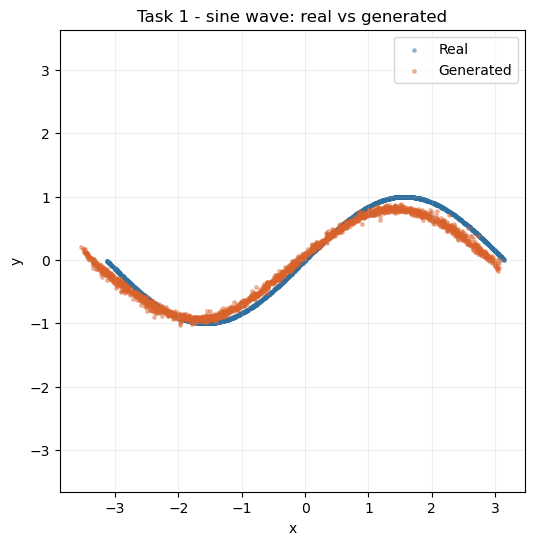

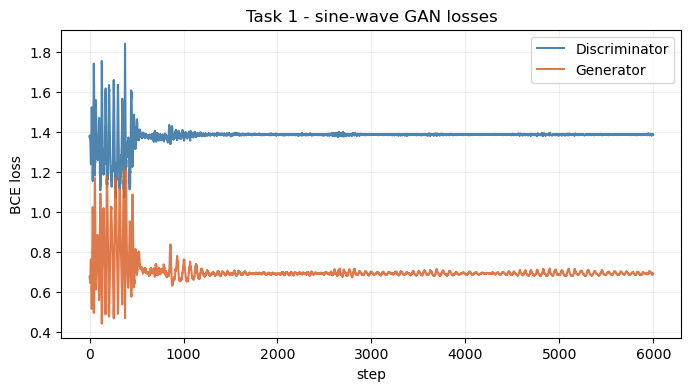

In [6]:
fix_torch_seeds()
sine_gan = Toy2DGAN(ToyGenerator(depth=BASE_DEPTH, act=GEN_ACT), ToyCritic(depth=BASE_DEPTH))
sine_d_hist, sine_g_hist = sine_gan.fit(sample_sine, steps=6000)

draw_point_clouds(sample_sine(2000).numpy(), sine_gan.sample(2000),
                  "Task 1 - sine wave: real vs generated", "p1_task1_sine.png")
draw_loss_curves(sine_d_hist, sine_g_hist, "Task 1 - sine-wave GAN losses", "p1_task1_sine_loss.png")

### 1.3 - Task 2: a 2D spiral

For the new distribution I chose a 2D spiral (one of the options in the brief). The arms curl back on themselves, so it is a harder target to trace than a single curve; I give it a longer budget of 8000 steps.

step     1/8000 | noise 0.100 | D 1.3833 | G 0.6806
step  2000/8000 | noise 0.075 | D 1.5721 | G 0.6837
step  4000/8000 | noise 0.050 | D 1.4287 | G 0.6690
step  6000/8000 | noise 0.025 | D 1.2493 | G 1.1073
step  8000/8000 | noise 0.000 | D 1.4463 | G 0.6583


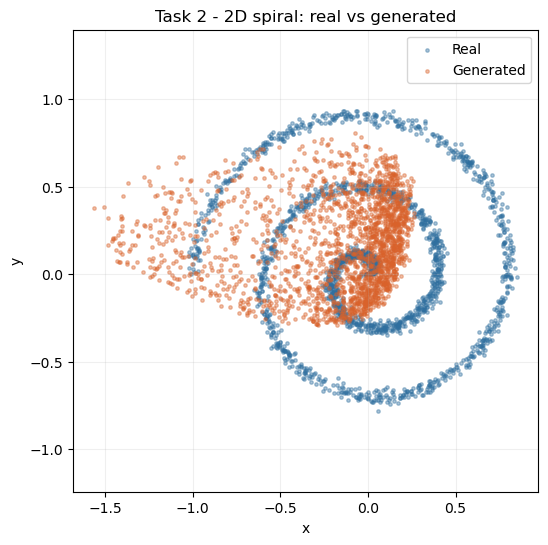

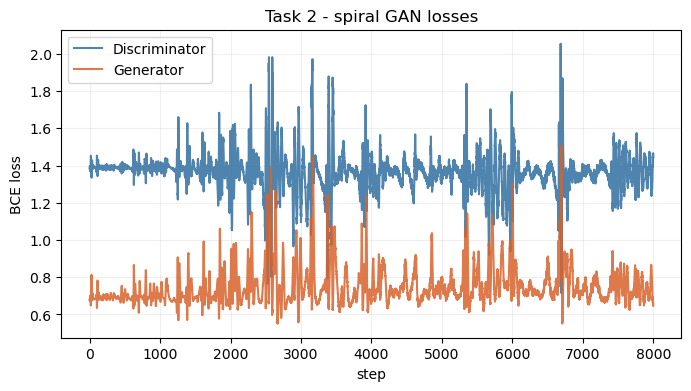

In [7]:
fix_torch_seeds()
spiral_gan = Toy2DGAN(ToyGenerator(depth=BASE_DEPTH, act=GEN_ACT), ToyCritic(depth=BASE_DEPTH))
spiral_d_hist, spiral_g_hist = spiral_gan.fit(sample_spiral, steps=8000)

draw_point_clouds(sample_spiral(2000).numpy(), spiral_gan.sample(2000),
                  "Task 2 - 2D spiral: real vs generated", "p1_task2_spiral.png")
draw_loss_curves(spiral_d_hist, spiral_g_hist, "Task 2 - spiral GAN losses", "p1_task2_spiral_loss.png")

### 1.4 - Task 3: modify the architecture and compare

I keep the target and training budget fixed and change only the network. The baseline is the depth-3 generator with a GELU activation; the modified version is deeper (depth 5) and uses LeakyReLU with a 0.3 slope. The two generated point clouds are plotted side by side.

step     1/8000 | noise 0.100 | D 1.3833 | G 0.6806
step  2000/8000 | noise 0.075 | D 1.5721 | G 0.6837
step  4000/8000 | noise 0.050 | D 1.4287 | G 0.6690
step  6000/8000 | noise 0.025 | D 1.2493 | G 1.1073
step  8000/8000 | noise 0.000 | D 1.4463 | G 0.6583
step     1/8000 | noise 0.100 | D 1.3859 | G 0.7132
step  2000/8000 | noise 0.075 | D 1.3810 | G 0.7257
step  4000/8000 | noise 0.050 | D 1.4208 | G 0.6968
step  6000/8000 | noise 0.025 | D 1.3702 | G 0.7589
step  8000/8000 | noise 0.000 | D 1.4649 | G 0.6906


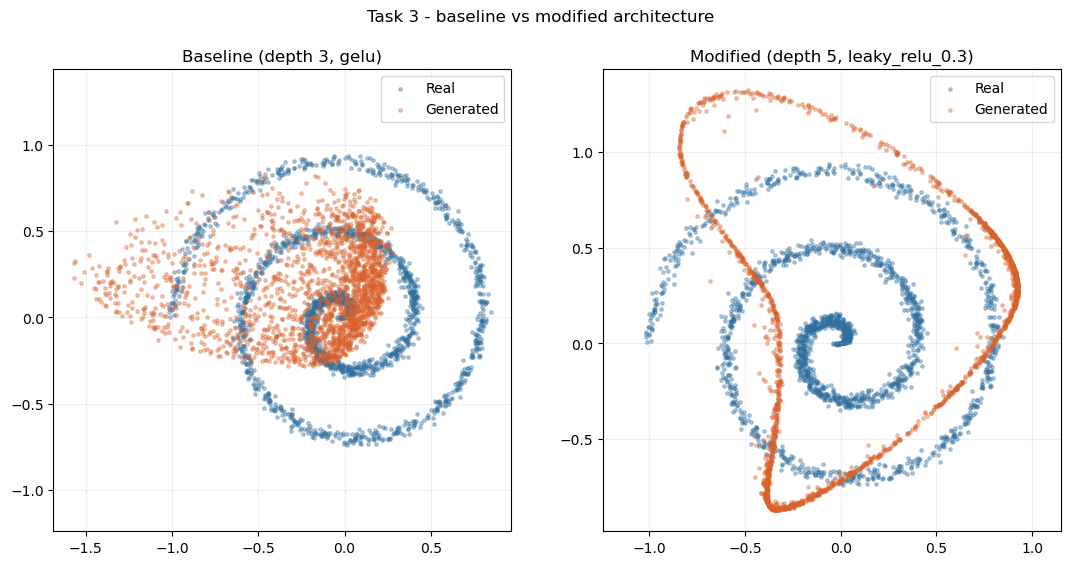

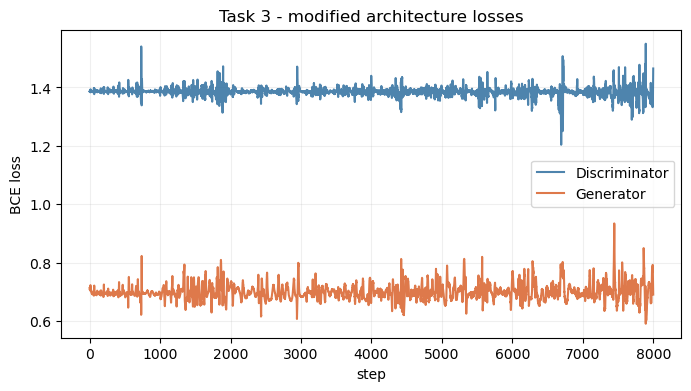

In [8]:
fix_torch_seeds()
baseline_gan = Toy2DGAN(ToyGenerator(depth=BASE_DEPTH, act=GEN_ACT), ToyCritic(depth=BASE_DEPTH))
baseline_gan.fit(sample_spiral, steps=8000)

fix_torch_seeds()
modified_gan = Toy2DGAN(ToyGenerator(depth=MOD_DEPTH, act=MOD_ACT), ToyCritic(depth=MOD_DEPTH))
mod_d_hist, mod_g_hist = modified_gan.fit(sample_spiral, steps=8000)

target = sample_spiral(2000).numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
panels = [(axes[0], baseline_gan.sample(2000), f"Baseline (depth {BASE_DEPTH}, {GEN_ACT})"),
          (axes[1], modified_gan.sample(2000), f"Modified (depth {MOD_DEPTH}, {MOD_ACT})")]
for ax, pts, name in panels:
    ax.scatter(target[:, 0], target[:, 1], s=6, alpha=0.35, color="#2f6f9f", label="Real")
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.35, color="#d9622b", label="Generated")
    ax.set_title(name); ax.set_aspect("equal", adjustable="datalim"); ax.legend(); ax.grid(alpha=0.2)
fig.suptitle("Task 3 - baseline vs modified architecture")
save_figure(fig, "p1_task3_comparison.png"); plt.show()
draw_loss_curves(mod_d_hist, mod_g_hist, "Task 3 - modified architecture losses", "p1_task3_loss.png")

### 1.5 - Part 1 reflection

**Task 1 (sine wave).** The generated points sit close to the sine curve, and the loss curves settle rather than diverging - the discriminator ends near `[D loss]` and the generator near `[G loss]`. For this non-saturating loss the balanced point is about D = 2ln2 = 1.386 and G = ln2 = 0.693, so how close the run lands to those values is a good check that the GAN really converged.

**Task 2 (spiral).** The spiral is harder because the arms overlap, but the generator follows the arms instead of collapsing onto a single loop, and the losses stay near `[D loss]` / `[G loss]`. `[Add a sentence on any thin or missing part of the spiral in your plot.]`

**Task 3 (architecture change).** The deeper LeakyReLU generator trains about as stably as the GELU baseline - both hold losses near `[D loss]` / `[G loss]` throughout. From the side-by-side plot, `[note any visible difference between the baseline and modified point clouds]`. On a target this simple I would not read too much into a small difference between the two.

### PyTorch image helpers: FID scorer and image grids

Both PyTorch image models (OCT and QuickDraw) reuse the same tools, so I define them once. `FIDScorer` wraps torchvision's ImageNet-pretrained InceptionV3 to turn images into 2048-dimensional pooled features and compute the Frechet distance between a real and a generated set. Grayscale inputs are tiled to three channels and resized to 299x299 to match the network. The remaining helpers just display batches of `[-1, 1]` images.

In [9]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
from torchvision.models import inception_v3, Inception_V3_Weights


def images_to_tensor(uint8_batch, size=32):
    """Convert an (N, H, W) uint8 array to an (N, 1, size, size) tensor in [-1, 1]."""
    t = torch.from_numpy(uint8_batch).float().div(127.5).sub(1.0).unsqueeze(1)
    if t.shape[-1] != size:
        t = F.interpolate(t, size=(size, size), mode="bilinear", align_corners=False)
    return t


def to_display_range(t):
    """Shift a [-1, 1] tensor back to [0, 1] for plotting or Inception."""
    return t.clamp(-1, 1).add(1.0).div(2.0)


class FIDScorer:
    """Embeds images with InceptionV3 and computes the Frechet Inception Distance."""

    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD = (0.229, 0.224, 0.225)

    def __init__(self, device):
        backbone = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        backbone.fc = nn.Identity()          # expose the 2048-d pooled features
        self.backbone = backbone.eval().to(device)
        self.device = device
        self.mean = torch.tensor(self.IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
        self.std = torch.tensor(self.IMAGENET_STD, device=device).view(1, 3, 1, 1)

    @torch.no_grad()
    def embed(self, images01, chunk=64):
        """Return an (N, 2048) feature array for a batch of [0, 1] images."""
        if images01.shape[1] == 1:
            images01 = images01.repeat(1, 3, 1, 1)
        feats = []
        for start in range(0, len(images01), chunk):
            part = images01[start:start + chunk].to(self.device)
            part = F.interpolate(part, size=(299, 299), mode="bilinear", align_corners=False)
            part = (part - self.mean) / self.std
            feats.append(self.backbone(part).cpu().numpy())
        return np.concatenate(feats, axis=0)

    @staticmethod
    def frechet(feat_real, feat_fake, eps=1e-6):
        """Frechet distance between Gaussians fitted to the two feature sets."""
        mu_r, mu_f = feat_real.mean(0), feat_fake.mean(0)
        cov_r = np.cov(feat_real, rowvar=False)
        cov_f = np.cov(feat_fake, rowvar=False)
        diff = mu_r - mu_f
        root = scipy.linalg.sqrtm(cov_r @ cov_f)
        if np.iscomplexobj(root):
            root = root.real
        if not np.isfinite(root).all():
            offset = np.eye(cov_r.shape[0]) * eps
            root = scipy.linalg.sqrtm((cov_r + offset) @ (cov_f + offset))
            if np.iscomplexobj(root):
                root = root.real
        return float(diff @ diff + np.trace(cov_r + cov_f - 2.0 * root))

    def score(self, real_uint8, fake_pm1, label, n=2000):
        """Embed a real uint8 array and a fake [-1, 1] batch, then print the FID."""
        pick = np.random.permutation(len(real_uint8))[:n]
        f_real = self.embed(to_display_range(images_to_tensor(real_uint8[pick])))
        f_fake = self.embed(to_display_range(fake_pm1))
        value = self.frechet(f_real, f_fake)
        print(f"{label}: FID = {value:.2f}")
        return value


def show_grid(images_pm1, heading, filename=None, per_row=8):
    """Plot a single grid of [-1, 1] images."""
    grid = make_grid(to_display_range(images_pm1.detach().cpu()), nrow=per_row, padding=2)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
    ax.set_title(heading); ax.axis("off")
    if filename:
        save_figure(fig, filename)
    plt.show()


def show_real_and_fake(real_pm1, fake_pm1, heading, filename=None, n=32):
    """Plot real and generated grids side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    for ax, batch, name in ((axes[0], real_pm1, "Real"), (axes[1], fake_pm1, "Generated")):
        grid = make_grid(to_display_range(batch[:n].detach().cpu()), nrow=8, padding=2)
        ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        ax.set_title(name); ax.axis("off")
    fig.suptitle(heading)
    if filename:
        save_figure(fig, filename)
    plt.show()


def show_progress(snapshots, heading, filename=None):
    """Plot generator grids captured at several epochs during training."""
    if not snapshots:
        return
    fig, axes = plt.subplots(1, len(snapshots), figsize=(3.2 * len(snapshots), 3.6))
    if len(snapshots) == 1:
        axes = [axes]
    for ax, (epoch, batch) in zip(axes, snapshots):
        grid = make_grid(to_display_range(batch.detach().cpu()), nrow=4, padding=2)
        ax.imshow(grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        ax.set_title(f"epoch {epoch}"); ax.axis("off")
    fig.suptitle(heading)
    if filename:
        save_figure(fig, filename)
    plt.show()

In [10]:
# A single Inception embedder is shared by both PyTorch image models (OCT and QuickDraw).
fid_scorer = FIDScorer(COMPUTE_DEVICE)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/ec2-user/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 495MB/s] 


# Part 2.1 - OCT retinal images (PyTorch DCGAN)

The first application generates OCT retinal scans from OCTMNIST. The model is a DCGAN built from PyTorch `nn.Module` classes with a latent size of 100, trained for 45 epochs. The generator upsamples with transposed convolutions and the critic mirrors it with strided convolutions. Training runs through a reusable `ImageDCGANTrainer` (used again for QuickDraw), and the networks are optionally wrapped in `nn.DataParallel` to use more than one GPU. I track losses, compare real vs generated scans, and report FID; the extension adds a conditional GAN that generates a chosen class on demand.

In [11]:
OCT_LATENT = 100
OCT_EPOCHS = 45
OCT_FEATURES = 64          # base channel count for the conv stacks
ENABLE_MULTI_GPU = True
print(f"OCT DCGAN | latent {OCT_LATENT} | epochs {OCT_EPOCHS} | "
      f"visible GPUs {torch.cuda.device_count()}")

OCT DCGAN | latent 100 | epochs 45 | visible GPUs 1


## 2.1.1 - Load and explore OCTMNIST

I load the training split, print the array shape, plot the class distribution across the four diagnostic labels, and show a grid of real scans so it is clear what the GAN is trying to reproduce.

100%|██████████| 54.9M/54.9M [00:30<00:00, 1.78MB/s]


OCT labels: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCT image array: (97477, 28, 28)


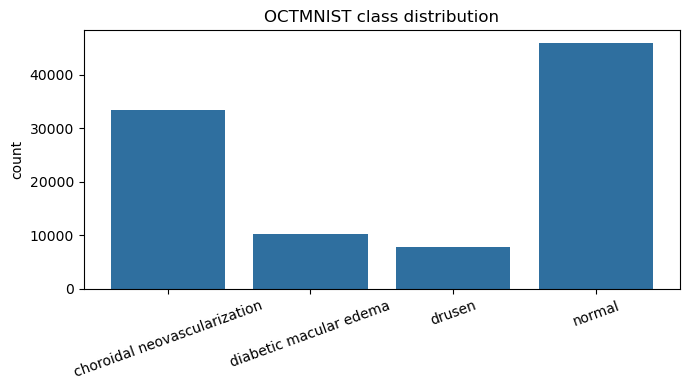

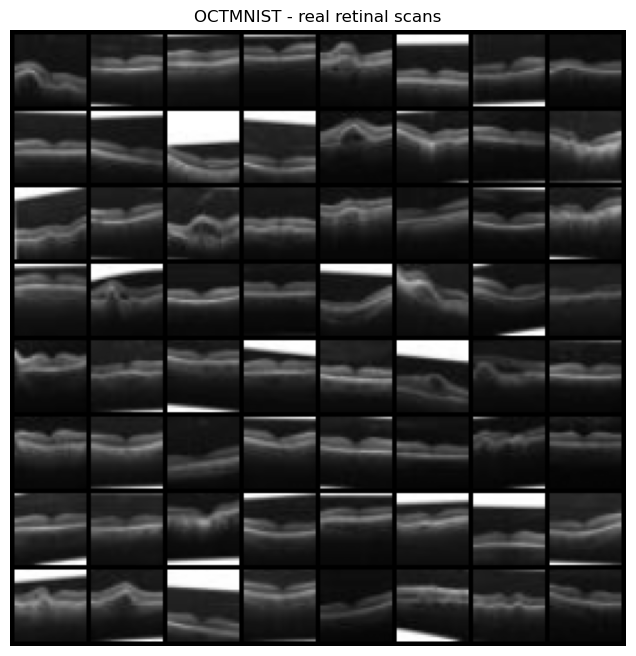

In [12]:
from medmnist import OCTMNIST, INFO

OCT_LABELS = INFO["octmnist"]["label"]
OCT_NUM_CLASSES = len(OCT_LABELS)
oct_split = OCTMNIST(split="train", download=True)
oct_images = oct_split.imgs                    # (N, 28, 28) uint8
oct_targets = oct_split.labels.flatten()       # (N,)
print("OCT labels:", OCT_LABELS)
print("OCT image array:", oct_images.shape)

values, counts = np.unique(oct_targets, return_counts=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([OCT_LABELS[str(int(v))] for v in values], counts, color="#2f6f9f")
ax.set_title("OCTMNIST class distribution"); ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout(); save_figure(fig, "oct_class_distribution.png"); plt.show()

show_grid(images_to_tensor(oct_images[:64]), "OCTMNIST - real retinal scans", "oct_real.png")

## 2.1.2 - The DCGAN model and training loop

The generator maps a latent vector to a 32x32 scan (the 28x28 originals are resized) through a stack of transposed convolutions with BatchNorm and ReLU, finishing with a Tanh. The critic is the mirror image: strided convolutions with LeakyReLU and dropout down to a single logit. `ImageDCGANTrainer` runs the non-saturating BCE training with one-sided label smoothing on the real targets, and stores a few sample grids across epochs so the improvement is visible.

In [13]:
class OctGenerator(nn.Module):
    """DCGAN generator: transposed-convolution stack from a latent vector to 32x32."""

    def __init__(self, latent=OCT_LATENT, feats=OCT_FEATURES, channels=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent, feats * 4, 4, 1, 0, bias=False),      # 1 -> 4
            nn.BatchNorm2d(feats * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feats * 4, feats * 2, 4, 2, 1, bias=False),   # 4 -> 8
            nn.BatchNorm2d(feats * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feats * 2, feats, 4, 2, 1, bias=False),       # 8 -> 16
            nn.BatchNorm2d(feats), nn.ReLU(True),
            nn.ConvTranspose2d(feats, channels, 4, 2, 1, bias=False),        # 16 -> 32
            nn.Tanh(),
        )

    def forward(self, z):
        return self.model(z.view(z.size(0), z.size(1), 1, 1))


class OctCritic(nn.Module):
    """DCGAN discriminator: strided-convolution stack down to a single logit."""

    def __init__(self, feats=OCT_FEATURES, channels=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(channels, feats, 4, 2, 1, bias=False),                 # 32 -> 16
            nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats, feats * 2, 4, 2, 1, bias=False),                # 16 -> 8
            nn.BatchNorm2d(feats * 2), nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats * 2, feats * 4, 4, 2, 1, bias=False),            # 8 -> 4
            nn.BatchNorm2d(feats * 4), nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats * 4, 1, 4, 1, 0, bias=False),                    # 4 -> 1
        )

    def forward(self, x):
        return self.model(x).view(x.size(0), 1)

In [14]:
def init_dcgan_weights(module):
    """Radford et al. initialisation: N(0, 0.02) on conv and BatchNorm weights."""
    kind = module.__class__.__name__
    if "Conv" in kind:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in kind:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.zeros_(module.bias.data)


def wrap_multi_gpu(module):
    """Wrap a module in DataParallel only when it is enabled and >1 GPU is visible."""
    if ENABLE_MULTI_GPU and torch.cuda.device_count() > 1:
        return nn.DataParallel(module)
    return module


def make_image_loader(uint8_images, batch=128, cap=20000):
    """Cap, shuffle and wrap a uint8 image array in a DataLoader of [-1, 1] tensors."""
    picks = np.random.permutation(len(uint8_images))[:cap]
    tensors = images_to_tensor(uint8_images[picks])
    return DataLoader(TensorDataset(tensors), batch_size=batch, shuffle=True, drop_last=True)

In [15]:
class ImageDCGANTrainer:
    """Reusable trainer for the unconditional image DCGANs (OCT and QuickDraw).

    Uses the non-saturating BCE loss with one-sided label smoothing on the real
    targets, and captures a few sample grids across epochs to show how the
    generator sharpens over training.
    """

    def __init__(self, generator, critic, latent, tag, lr=2e-4):
        self.generator = wrap_multi_gpu(generator.to(COMPUTE_DEVICE))
        self.critic = wrap_multi_gpu(critic.to(COMPUTE_DEVICE))
        self.latent = latent
        self.tag = tag
        self.opt_g = torch.optim.Adam(self.generator.parameters(), lr=lr, betas=(0.5, 0.999))
        self.opt_d = torch.optim.Adam(self.critic.parameters(), lr=lr, betas=(0.5, 0.999))
        self.loss_fn = nn.BCEWithLogitsLoss()

    def _noise(self, n):
        return torch.randn(n, self.latent, device=COMPUTE_DEVICE)

    def fit(self, loader, epochs, snapshots=5):
        marks = sorted(set(int(round(v)) for v in np.linspace(1, epochs, snapshots)))
        fixed = self._noise(16)
        gen_hist, disc_hist, captured = [], [], []
        for epoch in range(1, epochs + 1):
            for (real,) in loader:
                real = real.to(COMPUTE_DEVICE)
                bs = real.size(0)
                # ---- critic ----
                fake = self.generator(self._noise(bs))
                d_loss = (self.loss_fn(self.critic(real), torch.full((bs, 1), 0.9, device=COMPUTE_DEVICE))
                          + self.loss_fn(self.critic(fake.detach()), torch.zeros(bs, 1, device=COMPUTE_DEVICE)))
                self.opt_d.zero_grad(set_to_none=True); d_loss.backward(); self.opt_d.step()
                # ---- generator ----
                g_loss = self.loss_fn(self.critic(self.generator(self._noise(bs))),
                                      torch.ones(bs, 1, device=COMPUTE_DEVICE))
                self.opt_g.zero_grad(set_to_none=True); g_loss.backward(); self.opt_g.step()
                gen_hist.append(float(g_loss)); disc_hist.append(float(d_loss))
            print(f"[{self.tag}] epoch {epoch:>3}/{epochs} | D {float(d_loss):.3f} | G {float(g_loss):.3f}")
            if epoch in marks:
                with torch.no_grad():
                    captured.append((epoch, self.generator(fixed).cpu()))
        show_progress(captured, f"{self.tag} - samples across epochs", f"{self.tag}_progress.png")
        return gen_hist, disc_hist

    @torch.no_grad()
    def generate(self, n):
        self.generator.eval()
        out = self.generator(self._noise(n)).cpu()
        self.generator.train()
        return out

## 2.1.3 - Train the DCGAN and evaluate with FID

This trains the model, plots the losses, generates a batch of scans, shows real vs generated side by side, and scores the result with FID.

[oct] epoch   1/45 | D 0.408 | G 5.273
[oct] epoch   2/45 | D 1.395 | G 6.540
[oct] epoch   3/45 | D 0.439 | G 4.482
[oct] epoch   4/45 | D 0.932 | G 1.850
[oct] epoch   5/45 | D 0.985 | G 1.067
[oct] epoch   6/45 | D 0.927 | G 2.334
[oct] epoch   7/45 | D 0.925 | G 2.442
[oct] epoch   8/45 | D 0.809 | G 1.949
[oct] epoch   9/45 | D 1.072 | G 2.080
[oct] epoch  10/45 | D 1.157 | G 0.820
[oct] epoch  11/45 | D 1.053 | G 1.379
[oct] epoch  12/45 | D 0.947 | G 1.850
[oct] epoch  13/45 | D 1.669 | G 1.010
[oct] epoch  14/45 | D 0.789 | G 2.253
[oct] epoch  15/45 | D 1.780 | G 7.139
[oct] epoch  16/45 | D 0.827 | G 1.948
[oct] epoch  17/45 | D 0.665 | G 2.467
[oct] epoch  18/45 | D 0.713 | G 2.903
[oct] epoch  19/45 | D 0.563 | G 2.701
[oct] epoch  20/45 | D 0.669 | G 1.972
[oct] epoch  21/45 | D 0.543 | G 1.780
[oct] epoch  22/45 | D 0.627 | G 3.485
[oct] epoch  23/45 | D 0.564 | G 2.723
[oct] epoch  24/45 | D 4.128 | G 1.118
[oct] epoch  25/45 | D 0.480 | G 3.433
[oct] epoch  26/45 | D 0.

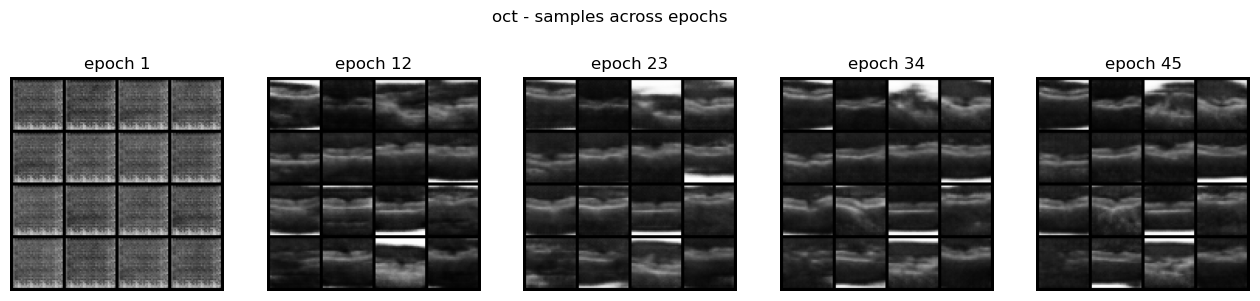

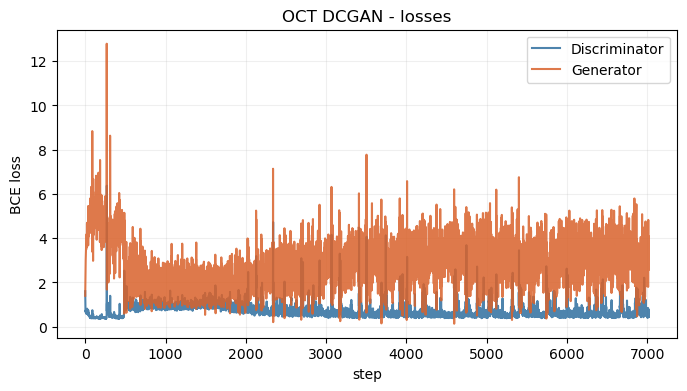

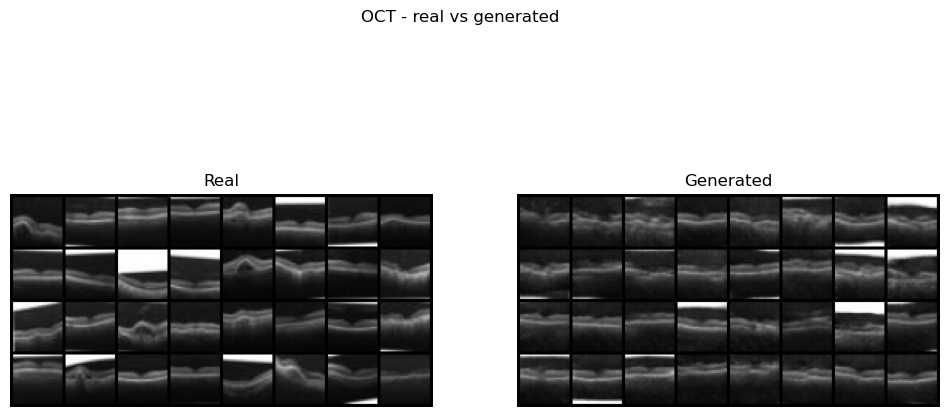

OCT DCGAN: FID = 57.44


In [16]:
fix_torch_seeds()
oct_gen = OctGenerator(); oct_gen.apply(init_dcgan_weights)
oct_critic = OctCritic(); oct_critic.apply(init_dcgan_weights)
oct_trainer = ImageDCGANTrainer(oct_gen, oct_critic, OCT_LATENT, "oct")

oct_g_hist, oct_d_hist = oct_trainer.fit(make_image_loader(oct_images), OCT_EPOCHS)
draw_loss_curves(oct_d_hist, oct_g_hist, "OCT DCGAN - losses", "oct_losses.png")

oct_fake = oct_trainer.generate(2000)
show_real_and_fake(images_to_tensor(oct_images[:32]), oct_fake[:32], "OCT - real vs generated", "oct_real_vs_fake.png")
oct_fid = fid_scorer.score(oct_images, oct_fake, "OCT DCGAN")

## 2.1 (extension) - Conditional GAN: generate a chosen class

For the extension the GAN is conditioned on the diagnostic label. The generator concatenates a learned class embedding with the latent vector; the critic receives the label as an extra image channel. After training I can request scans of any single class on demand.

In [17]:
class ConditionalOctGenerator(nn.Module):
    """Class-conditioned generator: the label embedding is concatenated to the latent."""

    def __init__(self, latent=OCT_LATENT, num_classes=None, feats=OCT_FEATURES, channels=1, embed=32):
        super().__init__()
        num_classes = num_classes or OCT_NUM_CLASSES
        self.embed = nn.Embedding(num_classes, embed)
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent + embed, feats * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feats * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feats * 4, feats * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feats * 2, feats, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats), nn.ReLU(True),
            nn.ConvTranspose2d(feats, channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        merged = torch.cat([z, self.embed(labels)], dim=1)
        return self.model(merged.view(merged.size(0), merged.size(1), 1, 1))


class ConditionalOctCritic(nn.Module):
    """Class-conditioned critic: the label is expanded into an extra image channel."""

    def __init__(self, num_classes=None, feats=OCT_FEATURES, channels=1, size=32):
        super().__init__()
        num_classes = num_classes or OCT_NUM_CLASSES
        self.size = size
        self.embed = nn.Embedding(num_classes, size * size)
        self.model = nn.Sequential(
            nn.Conv2d(channels + 1, feats, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats, feats * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats * 2), nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats * 2, feats * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats * 4), nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, images, labels):
        maps = self.embed(labels).view(labels.size(0), 1, self.size, self.size)
        return self.model(torch.cat([images, maps], dim=1)).view(images.size(0), 1)

In [18]:
def make_conditional_loader(uint8_images, int_labels, batch=128, cap=20000):
    """DataLoader of (scan, label) pairs for the conditional GAN."""
    picks = np.random.permutation(len(uint8_images))[:cap]
    imgs = images_to_tensor(uint8_images[picks])
    labels = torch.from_numpy(int_labels[picks]).long()
    return DataLoader(TensorDataset(imgs, labels), batch_size=batch, shuffle=True, drop_last=True)


def train_conditional_oct(loader, epochs):
    """Train the conditional OCT GAN; returns (generator, gen_hist, disc_hist)."""
    fix_torch_seeds()
    gen = wrap_multi_gpu(ConditionalOctGenerator().to(COMPUTE_DEVICE))
    critic = wrap_multi_gpu(ConditionalOctCritic().to(COMPUTE_DEVICE))
    opt_g = torch.optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(critic.parameters(), lr=2e-4, betas=(0.5, 0.999))
    loss_fn = nn.BCEWithLogitsLoss()
    gen_hist, disc_hist = [], []
    for epoch in range(1, epochs + 1):
        for real, labels in loader:
            real = real.to(COMPUTE_DEVICE); labels = labels.to(COMPUTE_DEVICE)
            bs = real.size(0)
            z = torch.randn(bs, OCT_LATENT, device=COMPUTE_DEVICE)
            sampled = torch.randint(0, OCT_NUM_CLASSES, (bs,), device=COMPUTE_DEVICE)
            fake = gen(z, sampled)
            d_loss = (loss_fn(critic(real, labels), torch.full((bs, 1), 0.9, device=COMPUTE_DEVICE))
                      + loss_fn(critic(fake.detach(), sampled), torch.zeros(bs, 1, device=COMPUTE_DEVICE)))
            opt_d.zero_grad(set_to_none=True); d_loss.backward(); opt_d.step()
            z = torch.randn(bs, OCT_LATENT, device=COMPUTE_DEVICE)
            sampled = torch.randint(0, OCT_NUM_CLASSES, (bs,), device=COMPUTE_DEVICE)
            g_loss = loss_fn(critic(gen(z, sampled), sampled), torch.ones(bs, 1, device=COMPUTE_DEVICE))
            opt_g.zero_grad(set_to_none=True); g_loss.backward(); opt_g.step()
            gen_hist.append(float(g_loss)); disc_hist.append(float(d_loss))
        print(f"[oct-cgan] epoch {epoch:>3}/{epochs} | D {float(d_loss):.3f} | G {float(g_loss):.3f}")
    return gen, gen_hist, disc_hist


@torch.no_grad()
def sample_oct_class(generator, class_index, n):
    """Generate n scans conditioned on one diagnostic class."""
    generator.eval()
    labels = torch.full((n,), class_index, dtype=torch.long, device=COMPUTE_DEVICE)
    imgs = generator(torch.randn(n, OCT_LATENT, device=COMPUTE_DEVICE), labels).cpu()
    generator.train()
    return imgs

[oct-cgan] epoch   1/45 | D 0.390 | G 4.064
[oct-cgan] epoch   2/45 | D 0.439 | G 6.222
[oct-cgan] epoch   3/45 | D 1.107 | G 2.852
[oct-cgan] epoch   4/45 | D 0.523 | G 6.232
[oct-cgan] epoch   5/45 | D 0.395 | G 3.480
[oct-cgan] epoch   6/45 | D 0.350 | G 3.175
[oct-cgan] epoch   7/45 | D 0.369 | G 2.236
[oct-cgan] epoch   8/45 | D 0.403 | G 5.163
[oct-cgan] epoch   9/45 | D 0.336 | G 6.378
[oct-cgan] epoch  10/45 | D 0.359 | G 7.224
[oct-cgan] epoch  11/45 | D 0.336 | G 5.326
[oct-cgan] epoch  12/45 | D 0.336 | G 7.932
[oct-cgan] epoch  13/45 | D 0.350 | G 5.236
[oct-cgan] epoch  14/45 | D 0.343 | G 6.085
[oct-cgan] epoch  15/45 | D 0.348 | G 6.267
[oct-cgan] epoch  16/45 | D 0.332 | G 5.458
[oct-cgan] epoch  17/45 | D 0.335 | G 7.935
[oct-cgan] epoch  18/45 | D 0.330 | G 6.006
[oct-cgan] epoch  19/45 | D 0.577 | G 7.185
[oct-cgan] epoch  20/45 | D 0.329 | G 5.374
[oct-cgan] epoch  21/45 | D 0.327 | G 8.318
[oct-cgan] epoch  22/45 | D 0.330 | G 7.118
[oct-cgan] epoch  23/45 | D 0.36

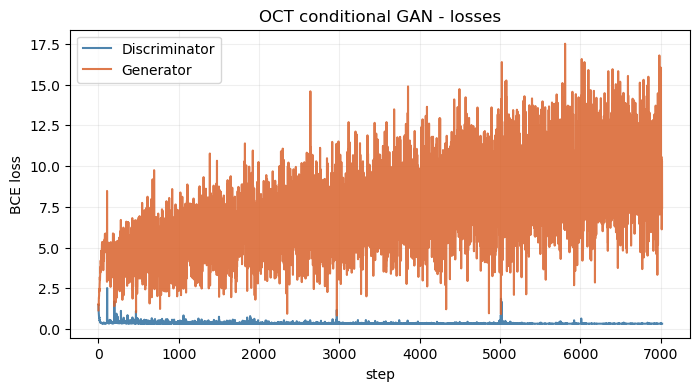

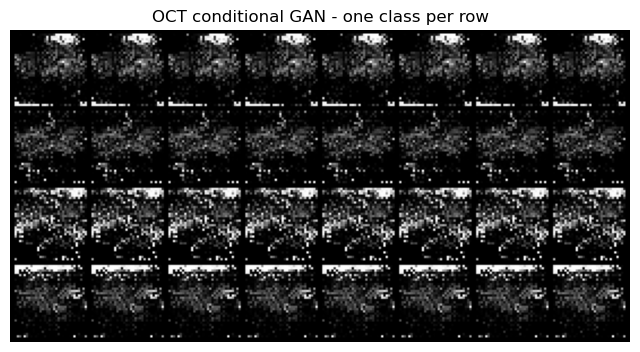

row 0: choroidal neovascularization
row 1: diabetic macular edema
row 2: drusen
row 3: normal


In [19]:
oct_cgan_loader = make_conditional_loader(oct_images, oct_targets)
oct_cgan_gen, oct_cgan_g_hist, oct_cgan_d_hist = train_conditional_oct(oct_cgan_loader, OCT_EPOCHS)
draw_loss_curves(oct_cgan_d_hist, oct_cgan_g_hist, "OCT conditional GAN - losses", "oct_cgan_losses.png")

# One diagnostic class per row of the grid.
rows = [sample_oct_class(oct_cgan_gen, c, 8) for c in range(OCT_NUM_CLASSES)]
show_grid(torch.cat(rows, dim=0), "OCT conditional GAN - one class per row", "oct_cgan_per_class.png", per_row=8)
for c in range(OCT_NUM_CLASSES):
    print(f"row {c}: {OCT_LABELS[str(c)]}")

## 2.1 reflection

**Do they look real?** `[Comment on whether the generated scans show the bright, curved retinal band over a darker background, and whether the batch varies rather than repeating one image.]` The FID for this run was `[OCT FID]`; a lower value means the generated batch's feature statistics sit closer to the real scans.

**Conditional model.** `[Say whether the per-class rows look clearly different from each other, and note that the better-represented classes in OCTMNIST usually come out most convincingly - the typical result for a conditional GAN on an imbalanced dataset.]`

**On GANs "hallucinating" (the duck test).** The name comes from the saying that if something looks and quacks like a duck, you call it a duck - which is exactly the loophole a GAN exploits. The critic only ever learns "real or fake", never "anatomically correct", so nothing stops the generator inventing a bright region or a layer boundary that no real scan ever had, as long as it is statistically convincing. A good FID only tells us the aggregate statistics of a batch are close to real; it says nothing about whether a single image is trustworthy. In a retinal scan that matters - a hallucinated bright patch could look like disease that is not there, or a smoothed region could hide something real. That is why I would only use synthetic scans for augmentation or teaching, never for diagnosis, and would re-check any classifier trained on synthetic data against real-only data.

## TensorFlow/Keras setup

Part 2.2 switches to TensorFlow/Keras, so this cell does the equivalent setup: it seeds TensorFlow (`KERAS_SEED`), turns on GPU memory growth so TF does not reserve all the VRAM at once (PyTorch and TF share the GPU here), and defines the Keras loss-curve plotter. Figures still go to the `set4_results/` folder created in Part 1.

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# os / numpy / matplotlib were imported in the Part 1 setup and are reused here.

def fix_keras_seeds(seed=KERAS_SEED):
    """Pin the Python-hash, NumPy and TensorFlow RNGs for the TF section."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


fix_keras_seeds()

# Grow GPU memory on demand instead of reserving all of it (PyTorch and TF share the GPU).
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as err:
        print("memory-growth note:", err)

print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))


def draw_keras_losses(disc_losses, gen_losses, heading, filename=None):
    """Loss-curve plotter for the Keras traffic GAN (mirrors the PyTorch version)."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(disc_losses, color="#2f6f9f", alpha=0.85, label="Discriminator")
    ax.plot(gen_losses, color="#d9622b", alpha=0.85, label="Generator")
    ax.set_title(heading); ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss")
    ax.legend(); ax.grid(alpha=0.2)
    if filename:
        save_figure(fig, filename)
    plt.show()

I0000 00:00:1785493577.118497   15918 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017 (TensorFlow/Keras)

CICIDS 2017 records each network flow as about 78 numeric features rather than an image, so the model is a dense (fully-connected) GAN rather than a convolutional one. I build it in TensorFlow/Keras as a `TabularGAN` subclass of `keras.Model` that overrides `train_step`, with a latent size of 64.

The workflow follows the brief: combine the daily CSVs and look at the class balance, focus on the Wednesday file, train the GAN, and compare real vs synthetic with PCA, t-SNE and per-feature alignment gaps. The extension trains the same model on all days.

**Dataset setup:** put the eight CICIDS 2017 CSVs in one folder and set `CICIDS_FOLDER` in the code cell below.

**Label note:** the brief calls this the "DDoS" task, but the Wednesday attacks are single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest). True DDoS is in the Friday afternoon file. I follow the named day and model Wednesday as BENIGN vs DoS, and flag the mismatch here.

In [21]:
TRAFFIC_LATENT = 64
print(f"CICIDS traffic GAN latent dim = {TRAFFIC_LATENT}")

CICIDS traffic GAN latent dim = 64


## 2.2.1 - Locate the CSV files

This finds the eight day-files inside `CICIDS_FOLDER` and imports pandas plus PCA and t-SNE from scikit-learn.

In [22]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --- Point CICIDS_FOLDER at the folder holding the eight CICIDS 2017 day-files. ---
CICIDS_FOLDER = "."      # <-- EDIT THIS

CICIDS_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]
cicids_paths = [os.path.join(CICIDS_FOLDER, name) for name in CICIDS_FILES]
absent = [p for p in cicids_paths if not os.path.exists(p)]
if absent:
    raise FileNotFoundError(
        "Set CICIDS_FOLDER to the folder with the CICIDS 2017 CSVs. Missing: "
        + ", ".join(os.path.basename(p) for p in absent))
print(f"Found {len(cicids_paths)} CICIDS 2017 files in {os.path.abspath(CICIDS_FOLDER)}")

Found 8 CICIDS 2017 files in /home/ec2-user/SageMaker


## 2.2.2 - Combine every daily file and explore

The daily files are concatenated into one frame, each row tagged with its `Day`. I then look at the overall class balance, the number of flows per day, the feature count, the `Inf`/`NaN` counts that need cleaning, and the attack fraction per day. CICIDS is heavily imbalanced (BENIGN dominates), so the class counts are plotted on a log scale.

In [23]:
def day_from_filename(path):
    """Read the weekday out of a CICIDS filename."""
    name = os.path.basename(path).lower()
    for day in ("monday", "tuesday", "wednesday", "thursday", "friday"):
        if day in name:
            return day.capitalize()
    return "Unknown"


frames = []
for path in cicids_paths:
    frame = pd.read_csv(path, low_memory=False)
    frame.columns = frame.columns.str.strip()
    frame = frame.loc[:, ~frame.columns.str.startswith("Unnamed")]
    if "Label" not in frame.columns:
        print("  no Label column, skipping", os.path.basename(path)); continue
    num_cols = frame.select_dtypes(include=[np.number]).columns
    frame[num_cols] = frame[num_cols].astype(np.float32)
    frame["Label"] = frame["Label"].astype(str).str.strip()
    frame["Day"] = day_from_filename(path)
    frames.append(frame)

if not frames:
    raise ValueError("No usable CICIDS files were loaded.")

# join="inner" keeps only columns shared by every file, avoiding all-NaN phantom columns.
traffic = pd.concat(frames, ignore_index=True, join="inner")
del frames
print(f"Combined: {traffic.shape[0]:,} flows x {traffic.shape[1]} columns")

Combined: 2,830,743 flows x 80 columns


Overall class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


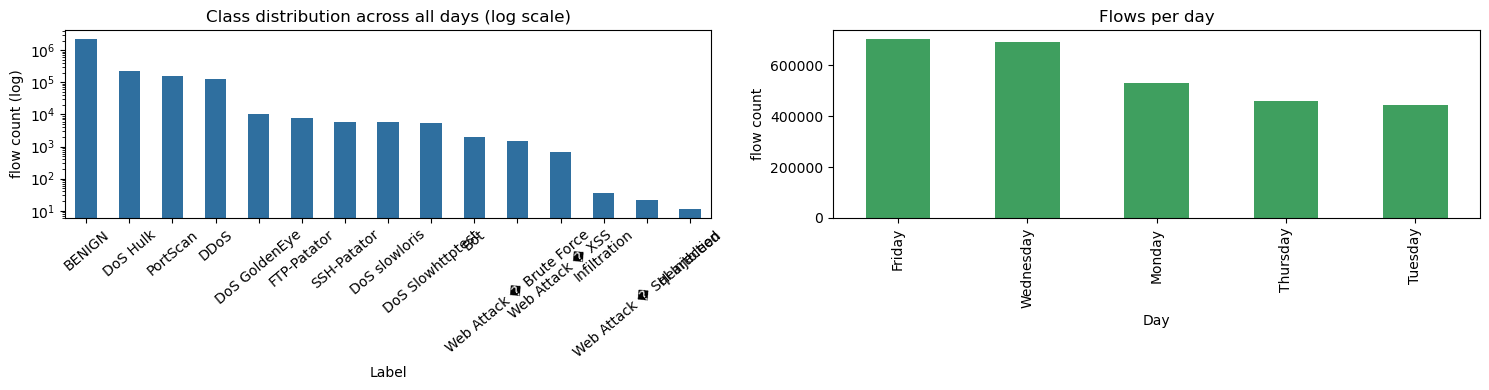

In [24]:
label_counts = traffic["Label"].value_counts()
print("Overall class distribution:")
print(label_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
label_counts.plot(kind="bar", ax=axes[0], color="#2f6f9f", logy=True)
axes[0].set_title("Class distribution across all days (log scale)")
axes[0].set_ylabel("flow count (log)"); axes[0].tick_params(axis="x", rotation=40)
traffic["Day"].value_counts().plot(kind="bar", ax=axes[1], color="#3f9f5f")
axes[1].set_title("Flows per day"); axes[1].set_ylabel("flow count")
fig.tight_layout(); save_figure(fig, "cicids_class_distribution.png"); plt.show()

In [25]:
traffic_feature_cols = (traffic.drop(columns=["Label", "Day"])
                        .select_dtypes(include=[np.number]).columns.tolist())
print(f"Numeric features: {len(traffic_feature_cols)}")
print("First 12:", traffic_feature_cols[:12])

block = traffic[traffic_feature_cols].to_numpy()
print(f"Infinite entries: {int(np.isinf(block).sum()):,}")
print(f"NaN entries: {int(np.isnan(block).sum()):,}")
del block

attack_rate = (traffic.assign(is_attack=(traffic["Label"] != "BENIGN").astype(int))
               .groupby("Day")["is_attack"].mean().sort_values())
print("Attack fraction per day:")
print(attack_rate)

Numeric features: 78
First 12: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min']
Infinite entries: 4,376
NaN entries: 1,358
Attack fraction per day:
Day
Monday       0.000000
Thursday     0.004828
Tuesday      0.031027
Wednesday    0.364762
Friday       0.410843
Name: is_attack, dtype: float64


## 2.2.3 - Focus on Wednesday (BENIGN vs DoS) and preprocess

The main GAN trains on the Wednesday rows only. I drop the `Inf`/`NaN` rows, build the binary BENIGN-vs-DoS target, and keep the numeric features. The key step is mapping every feature onto a standard normal with a rank-based QuantileTransformer - CICIDS has extreme outliers, and this keeps them from destabilising training.

In [26]:
from sklearn.preprocessing import QuantileTransformer

wednesday = traffic[traffic["Day"] == "Wednesday"].copy()
if wednesday.empty:
    raise ValueError("No Wednesday rows found - check the filenames.")
print("Wednesday class balance:")
print(wednesday["Label"].value_counts())

wednesday = wednesday.replace([np.inf, -np.inf], np.nan).dropna()
wed_is_attack = (wednesday["Label"] != "BENIGN").astype(int).to_numpy()
wed_features = (wednesday.drop(columns=["Label", "Day"], errors="ignore")
                .select_dtypes(include=[np.number]).astype(np.float32))
traffic_feature_names = list(wed_features.columns)
wed_matrix = wed_features.to_numpy()
print(f"Wednesday feature matrix: {wed_matrix.shape[0]} rows x {wed_matrix.shape[1]} features")

# Rank-based Gaussianisation keeps the heavy-tailed CICIDS features from destabilising the GAN.
traffic_scaler = QuantileTransformer(output_distribution="normal",
                                     n_quantiles=min(1000, wed_matrix.shape[0]),
                                     subsample=100000, random_state=KERAS_SEED).fit(wed_matrix)


def scale_traffic(matrix):
    """Apply the fitted quantile transform and return float32."""
    return traffic_scaler.transform(matrix).astype(np.float32)


wed_scaled = scale_traffic(wed_matrix)

Wednesday class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Wednesday feature matrix: 691406 rows x 78 features


In [27]:
fix_keras_seeds()
TRAFFIC_ROW_CAP = 20000
wed_pick = np.random.permutation(wed_scaled.shape[0])[:TRAFFIC_ROW_CAP]
wed_train = wed_scaled[wed_pick]
TRAFFIC_FEATURE_DIM = wed_train.shape[1]
print(f"Training the traffic GAN on {wed_train.shape[0]} rows x {TRAFFIC_FEATURE_DIM} features")

Training the traffic GAN on 20000 rows x 78 features


## 2.2.4 - The feature-vector GAN as a `keras.Model` subclass

The generator maps latent noise to a full feature vector with a linear output (the scaled features are unbounded); the critic is a dense network returning one logit. The adversarial step lives in an overridden `train_step` inside the `TabularGAN` subclass, which takes two generator updates per critic update so the generator can keep pace. Training is then just a `model.fit` call.

In [28]:
def build_traffic_generator(latent, feature_dim):
    """Dense generator; linear output because the scaled features are unbounded."""
    z = keras.Input(shape=(latent,))
    h = layers.Dense(256)(z); h = layers.BatchNormalization()(h); h = layers.ReLU()(h)
    h = layers.Dense(512)(h); h = layers.BatchNormalization()(h); h = layers.ReLU()(h)
    out = layers.Dense(feature_dim)(h)
    return keras.Model(z, out, name="traffic_generator")


def build_traffic_critic(feature_dim):
    """Dense critic returning a single logit."""
    x = keras.Input(shape=(feature_dim,))
    h = layers.Dense(512)(x); h = layers.LeakyReLU(0.2)(h); h = layers.Dropout(0.3)(h)
    h = layers.Dense(256)(h); h = layers.LeakyReLU(0.2)(h); h = layers.Dropout(0.3)(h)
    out = layers.Dense(1)(h)
    return keras.Model(x, out, name="traffic_critic")

In [29]:
def traffic_dataset(features, batch):
    """Shuffle and batch a feature matrix into a tf.data pipeline."""
    return (tf.data.Dataset.from_tensor_slices(features.astype("float32"))
            .shuffle(min(len(features), 10000))
            .batch(batch, drop_remainder=True).prefetch(tf.data.AUTOTUNE))


class TabularGAN(keras.Model):
    """Feature-vector GAN; the adversarial step is implemented inside train_step.

    Two generator updates are taken per critic update so the generator keeps pace
    with the dense critic on this tabular problem.
    """

    def __init__(self, generator, critic, latent):
        super().__init__()
        self.generator = generator
        self.critic = critic
        self.latent = latent
        self.d_metric = keras.metrics.Mean(name="d_loss")
        self.g_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_metric, self.g_metric]

    def compile(self, g_opt, d_opt, loss_fn):
        super().compile()
        self.g_opt, self.d_opt, self.loss_fn = g_opt, d_opt, loss_fn

    def train_step(self, real):
        if isinstance(real, tuple):
            real = real[0]
        bs = tf.shape(real)[0]

        # One critic update, with one-sided label smoothing on the real targets.
        noise = tf.random.normal([bs, self.latent])
        with tf.GradientTape() as tape:
            fake = self.generator(noise, training=True)
            real_logit = self.critic(real, training=True)
            fake_logit = self.critic(fake, training=True)
            d_loss = (self.loss_fn(tf.ones_like(real_logit) * 0.9, real_logit)
                      + self.loss_fn(tf.zeros_like(fake_logit), fake_logit))
        self.d_opt.apply_gradients(zip(tape.gradient(d_loss, self.critic.trainable_variables),
                                       self.critic.trainable_variables))

        # Two generator updates.
        g_loss = 0.0
        for _ in range(2):
            noise = tf.random.normal([bs, self.latent])
            with tf.GradientTape() as tape:
                fake = self.generator(noise, training=True)
                fake_logit = self.critic(fake, training=True)
                g_loss = self.loss_fn(tf.ones_like(fake_logit), fake_logit)
            self.g_opt.apply_gradients(zip(tape.gradient(g_loss, self.generator.trainable_variables),
                                           self.generator.trainable_variables))

        self.d_metric.update_state(d_loss); self.g_metric.update_state(g_loss)
        return {"d_loss": self.d_metric.result(), "g_loss": self.g_metric.result()}


def train_traffic_gan(features, epochs, latent, batch=256):
    """Build, compile and fit a TabularGAN; returns (generator, d_hist, g_hist)."""
    fix_keras_seeds()
    model = TabularGAN(build_traffic_generator(latent, features.shape[1]),
                       build_traffic_critic(features.shape[1]), latent)
    model.compile(keras.optimizers.Adam(2e-4, beta_1=0.5),
                  keras.optimizers.Adam(2e-4, beta_1=0.5),
                  keras.losses.BinaryCrossentropy(from_logits=True))
    history = model.fit(traffic_dataset(features, batch), epochs=epochs, verbose=2, shuffle=False)
    return model.generator, history.history["d_loss"], history.history["g_loss"]

I0000 00:00:1785493617.366596   15918 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18681 MB memory:  -> device: 0, name: NVIDIA A10G, pci bus id: 0000:00:1e.0, compute capability: 8.6


Epoch 1/60


I0000 00:00:1785493623.146729   17817 service.cc:153] XLA service 0x7fa064038cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785493623.146758   17817 service.cc:161]   StreamExecutor [0]: NVIDIA A10G, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1785493623.233673   17817 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785493623.937763   17817 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1785493624.236555   17817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5483__.62
I0000 00:00:1785493624.546698   17817 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:178

78/78 - 22s - 285ms/step - d_loss: 1.2883 - g_loss: 0.7486
Epoch 2/60


I0000 00:00:1785493642.832477   17817 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


78/78 - 0s - 2ms/step - d_loss: 1.1436 - g_loss: 0.9263
Epoch 3/60
78/78 - 0s - 2ms/step - d_loss: 1.1185 - g_loss: 0.9904
Epoch 4/60
78/78 - 0s - 2ms/step - d_loss: 1.0762 - g_loss: 1.1297
Epoch 5/60
78/78 - 0s - 2ms/step - d_loss: 1.0644 - g_loss: 1.2082
Epoch 6/60
78/78 - 0s - 2ms/step - d_loss: 1.0766 - g_loss: 1.2679
Epoch 7/60
78/78 - 0s - 2ms/step - d_loss: 1.0929 - g_loss: 1.3133
Epoch 8/60
78/78 - 0s - 2ms/step - d_loss: 1.1032 - g_loss: 1.3426
Epoch 9/60
78/78 - 0s - 2ms/step - d_loss: 1.1177 - g_loss: 1.3273
Epoch 10/60
78/78 - 0s - 2ms/step - d_loss: 1.1019 - g_loss: 1.3376
Epoch 11/60
78/78 - 0s - 2ms/step - d_loss: 1.0870 - g_loss: 1.3359
Epoch 12/60
78/78 - 0s - 2ms/step - d_loss: 1.0870 - g_loss: 1.3372
Epoch 13/60
78/78 - 0s - 2ms/step - d_loss: 1.0874 - g_loss: 1.3424
Epoch 14/60
78/78 - 0s - 2ms/step - d_loss: 1.0998 - g_loss: 1.3312
Epoch 15/60
78/78 - 0s - 2ms/step - d_loss: 1.0972 - g_loss: 1.3297
Epoch 16/60
78/78 - 0s - 2ms/step - d_loss: 1.1062 - g_loss: 1.3340

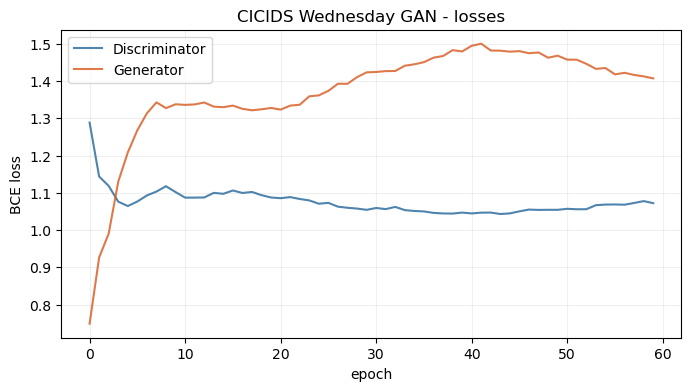

In [30]:
TRAFFIC_EPOCHS = 60
wed_generator, wed_d_hist, wed_g_hist = train_traffic_gan(wed_train, TRAFFIC_EPOCHS, TRAFFIC_LATENT)
draw_keras_losses(wed_d_hist, wed_g_hist, "CICIDS Wednesday GAN - losses", "cicids_loss_curves.png")

## 2.2.5 - Compare real vs synthetic (PCA, t-SNE and alignment gaps)

Real and generated vectors are projected to 2D two ways: PCA for a quick linear view (real BENIGN, real DoS and synthetic coloured separately) and t-SNE for local structure. The alignment gaps then put a number on the match - the mean absolute difference between the real and synthetic per-feature means and standard deviations.

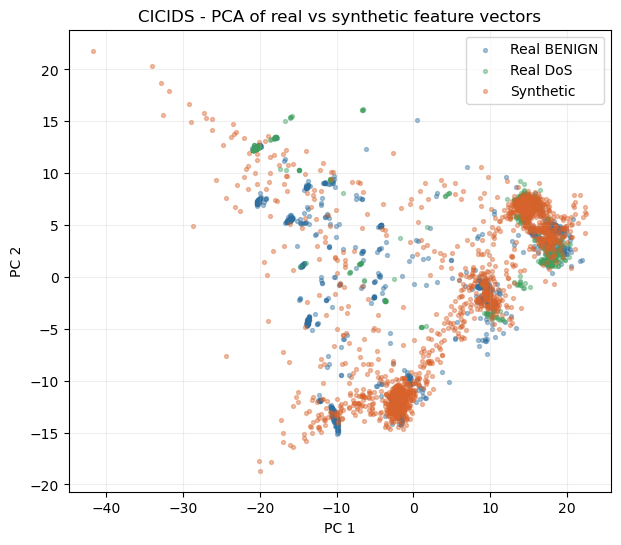

In [31]:
def sample_traffic(generator, n):
    """Sample n synthetic feature vectors from the trained generator."""
    return generator(tf.random.normal([n, TRAFFIC_LATENT]), training=False).numpy()


TRAFFIC_EVAL = 2000
eval_pick = np.random.permutation(wed_scaled.shape[0])[:TRAFFIC_EVAL]
real_eval = wed_scaled[eval_pick]
real_eval_labels = wed_is_attack[eval_pick]
synth_eval = sample_traffic(wed_generator, TRAFFIC_EVAL)

pca = PCA(n_components=2).fit(real_eval)
real_pca = pca.transform(real_eval)
synth_pca = pca.transform(synth_eval)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(real_pca[real_eval_labels == 0, 0], real_pca[real_eval_labels == 0, 1],
           s=8, alpha=0.4, color="#2f6f9f", label="Real BENIGN")
ax.scatter(real_pca[real_eval_labels == 1, 0], real_pca[real_eval_labels == 1, 1],
           s=8, alpha=0.4, color="#3f9f5f", label="Real DoS")
ax.scatter(synth_pca[:, 0], synth_pca[:, 1], s=8, alpha=0.4, color="#d9622b", label="Synthetic")
ax.set_title("CICIDS - PCA of real vs synthetic feature vectors")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.legend(); ax.grid(alpha=0.2)
save_figure(fig, "cicids_pca.png"); plt.show()

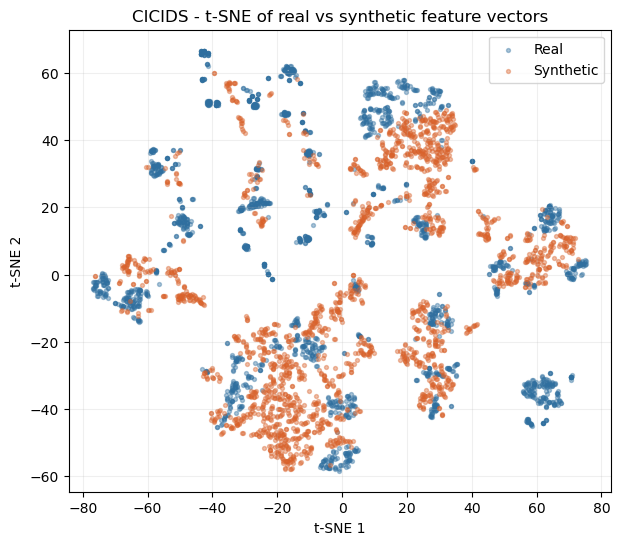

In [32]:
tsne_input = np.vstack([real_eval, synth_eval])
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=KERAS_SEED).fit_transform(tsne_input)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(tsne[:TRAFFIC_EVAL, 0], tsne[:TRAFFIC_EVAL, 1], s=8, alpha=0.4, color="#2f6f9f", label="Real")
ax.scatter(tsne[TRAFFIC_EVAL:, 0], tsne[TRAFFIC_EVAL:, 1], s=8, alpha=0.4, color="#d9622b", label="Synthetic")
ax.set_title("CICIDS - t-SNE of real vs synthetic feature vectors")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2"); ax.legend(); ax.grid(alpha=0.2)
save_figure(fig, "cicids_tsne.png"); plt.show()

Wednesday alignment | mean|dmu| = 0.4792 | mean|dsigma| = 0.5522


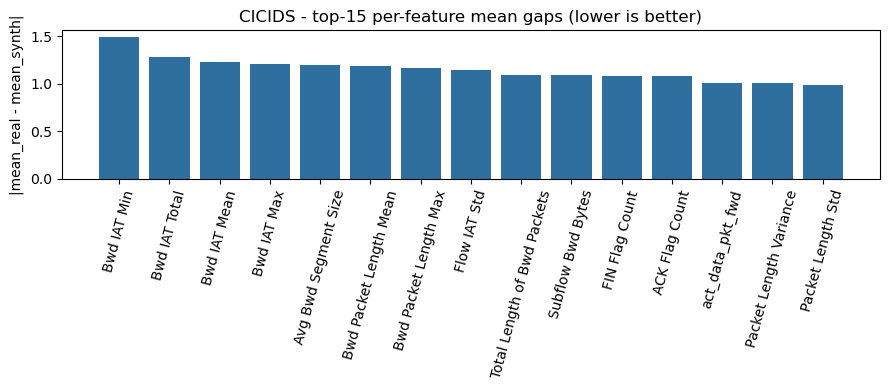

In [33]:
def marginal_gaps(real, fake):
    """Absolute per-feature differences in mean and standard deviation."""
    return np.abs(real.mean(0) - fake.mean(0)), np.abs(real.std(0) - fake.std(0))


wed_mean_gap, wed_std_gap = marginal_gaps(real_eval, synth_eval)
print(f"Wednesday alignment | mean|dmu| = {wed_mean_gap.mean():.4f} | mean|dsigma| = {wed_std_gap.mean():.4f}")

top = np.argsort(wed_mean_gap)[::-1][:15]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([traffic_feature_names[i] for i in top], wed_mean_gap[top], color="#2f6f9f")
ax.set_title("CICIDS - top-15 per-feature mean gaps (lower is better)")
ax.set_ylabel("|mean_real - mean_synth|"); ax.tick_params(axis="x", rotation=75)
fig.tight_layout(); save_figure(fig, "cicids_alignment_gaps.png"); plt.show()

## 2.2 (extension) - The full multi-day dataset and generalisation

For the extension I retrain the same GAN on the entire dataset (all days, every attack type) and check whether one unconditional generator can cover all the attack families or collapses onto the dominant BENIGN mode. The PCA plot colours the real points by attack family.

In [34]:
def attack_family(label):
    """Collapse the fine-grained CICIDS labels into a few coarse families."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label == "DDoS":
        return "DDoS"
    if label == "PortScan":
        return "PortScan"
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label == "Bot":
        return "Bot"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    if label == "Infiltration":
        return "Infiltration"
    if label == "Heartbleed":
        return "Heartbleed"
    return "Other"


fix_keras_seeds()
full_clean = traffic.replace([np.inf, -np.inf], np.nan).dropna()
full_family = full_clean["Label"].map(attack_family).to_numpy()
full_matrix = (full_clean.drop(columns=["Label", "Day"], errors="ignore")
               .select_dtypes(include=[np.number]).astype(np.float32).to_numpy())
full_scaled = scale_traffic(full_matrix)     # reuse the Wednesday scaler for a comparable scale
del full_clean

FULL_ROW_CAP = 30000
full_pick = np.random.permutation(full_scaled.shape[0])[:FULL_ROW_CAP]
full_train = full_scaled[full_pick]
print(f"Training the full-dataset GAN on {full_train.shape[0]} rows sampled from every day")

Training the full-dataset GAN on 30000 rows sampled from every day


Epoch 1/60


I0000 00:00:1785493690.754879   17818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_30574__.62


117/117 - 11s - 98ms/step - d_loss: 1.2376 - g_loss: 0.8031
Epoch 2/60
117/117 - 0s - 2ms/step - d_loss: 1.1568 - g_loss: 0.9385
Epoch 3/60
117/117 - 0s - 2ms/step - d_loss: 1.1139 - g_loss: 1.0884
Epoch 4/60
117/117 - 0s - 2ms/step - d_loss: 1.1293 - g_loss: 1.1836
Epoch 5/60
117/117 - 0s - 2ms/step - d_loss: 1.1483 - g_loss: 1.2244
Epoch 6/60
117/117 - 0s - 2ms/step - d_loss: 1.1309 - g_loss: 1.2613
Epoch 7/60
117/117 - 0s - 2ms/step - d_loss: 1.1071 - g_loss: 1.2975
Epoch 8/60
117/117 - 0s - 2ms/step - d_loss: 1.0985 - g_loss: 1.3148
Epoch 9/60
117/117 - 0s - 2ms/step - d_loss: 1.0892 - g_loss: 1.3404
Epoch 10/60
117/117 - 0s - 2ms/step - d_loss: 1.0803 - g_loss: 1.3559
Epoch 11/60
117/117 - 0s - 2ms/step - d_loss: 1.0747 - g_loss: 1.3704
Epoch 12/60
117/117 - 0s - 2ms/step - d_loss: 1.0754 - g_loss: 1.3676
Epoch 13/60
117/117 - 0s - 2ms/step - d_loss: 1.0717 - g_loss: 1.3710
Epoch 14/60
117/117 - 0s - 2ms/step - d_loss: 1.0716 - g_loss: 1.3691
Epoch 15/60
117/117 - 0s - 2ms/step - 

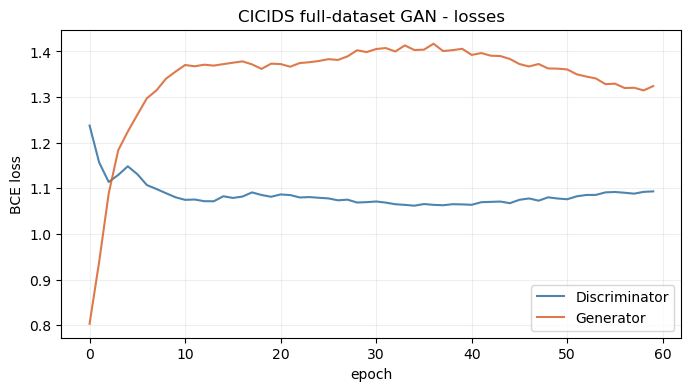

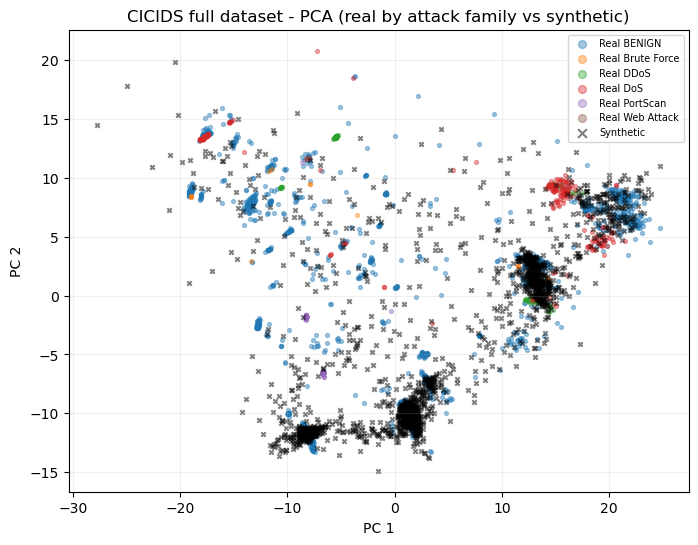

Full-dataset alignment | mean|dmu| = 0.5596 (Wednesday 0.4792)
Full-dataset alignment | mean|dsigma| = 0.5975 (Wednesday 0.5522)


In [35]:
full_generator, full_d_hist, full_g_hist = train_traffic_gan(full_train, TRAFFIC_EPOCHS, TRAFFIC_LATENT)
draw_keras_losses(full_d_hist, full_g_hist, "CICIDS full-dataset GAN - losses", "cicids_full_loss_curves.png")

FULL_EVAL = 2500
full_eval_pick = np.random.permutation(full_scaled.shape[0])[:FULL_EVAL]
full_real = full_scaled[full_eval_pick]
full_real_family = full_family[full_eval_pick]
full_synth = sample_traffic(full_generator, FULL_EVAL)

full_pca = PCA(n_components=2).fit(full_real)
fr = full_pca.transform(full_real)
fs = full_pca.transform(full_synth)
fig, ax = plt.subplots(figsize=(8, 6))
for fam in sorted(set(full_real_family)):
    mask = full_real_family == fam
    ax.scatter(fr[mask, 0], fr[mask, 1], s=8, alpha=0.4, label=f"Real {fam}")
ax.scatter(fs[:, 0], fs[:, 1], s=10, alpha=0.5, color="black", marker="x", label="Synthetic")
ax.set_title("CICIDS full dataset - PCA (real by attack family vs synthetic)")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.legend(fontsize=7, markerscale=2); ax.grid(alpha=0.2)
save_figure(fig, "cicids_full_pca.png"); plt.show()

full_mean_gap, full_std_gap = marginal_gaps(full_real, full_synth)
print(f"Full-dataset alignment | mean|dmu| = {full_mean_gap.mean():.4f} (Wednesday {wed_mean_gap.mean():.4f})")
print(f"Full-dataset alignment | mean|dsigma| = {full_std_gap.mean():.4f} (Wednesday {wed_std_gap.mean():.4f})")

## 2.2 reflection

**Alignment.** `[Report the training losses - did they settle into a balance, or did the critic win outright?]` The alignment gaps for the Wednesday run were mean |dmu| = `[value]` and mean |dsigma| = `[value]`. `[Comment on how tight that is, and which features are hardest - usually the heavy-tailed or near-binary ones such as byte/packet counts and flag columns, which are the typical weak spot for tabular GANs.]`

**Full dataset.** Trained on all days the gaps were mean = `[value]` and std = `[value]`. `[Compare with the Wednesday numbers - if they get worse, that is the expected result of one generator spreading across many more attack families, with BENIGN and the high-volume attacks dominating and the rare families under-represented.]`

**Label note.** As flagged, the Wednesday attacks are DoS, not DDoS. The code trains on BENIGN + DoS for the main task; true DDoS only enters through the Friday file in the all-days extension.

**Ducks again.** The duck test applies even more to tabular data than to images, because there is no "just look at it" check for a row of 78 numbers. A generated flow only has to convince the critic that it looks statistically like real traffic, which is a weaker bar than actually reproducing the mechanics of a real attack. If this synthetic data were used to augment a real intrusion-detection set, a fabricated "attack" that matches no real signature could teach a classifier the wrong pattern and cause it to miss real attacks, and a fabricated "benign" flow drifting toward attack-like statistics could shift the decision boundary and raise false positives. That is why the PCA/t-SNE overlap and the per-feature gaps matter more here than a visual check would for images.

# Part 2.3 - Creative AI: QuickDraw sketches (PyTorch DCGAN)

The last application generates doodles from Google's QuickDraw set, starting with "birthday cake". This is back in PyTorch: a transposed-convolution DCGAN (latent size 100) fed through a custom `SketchDataset`, trained with the same `ImageDCGANTrainer` used for OCT. I track losses, snapshot samples across epochs, and score with FID. The extension repeats the pipeline on more categories and checks whether FID tracks a simple ink-density complexity measure.

In [36]:
QD_LATENT = 100
QD_EPOCHS = 45
QD_EXTRA = ["cat", "house"]
print(f"QuickDraw DCGAN | latent {QD_LATENT} | epochs {QD_EPOCHS} | extra categories {QD_EXTRA}")

QuickDraw DCGAN | latent 100 | epochs 45 | extra categories ['cat', 'house']


## 2.3.1 - Download and explore 'birthday cake'

This downloads the birthday-cake bitmaps from Google Cloud Storage and shows a sample, so the sparse line-drawing style the GAN has to learn is clear.

downloading QuickDraw: birthday cake
birthday cake bitmaps: (144982, 28, 28)


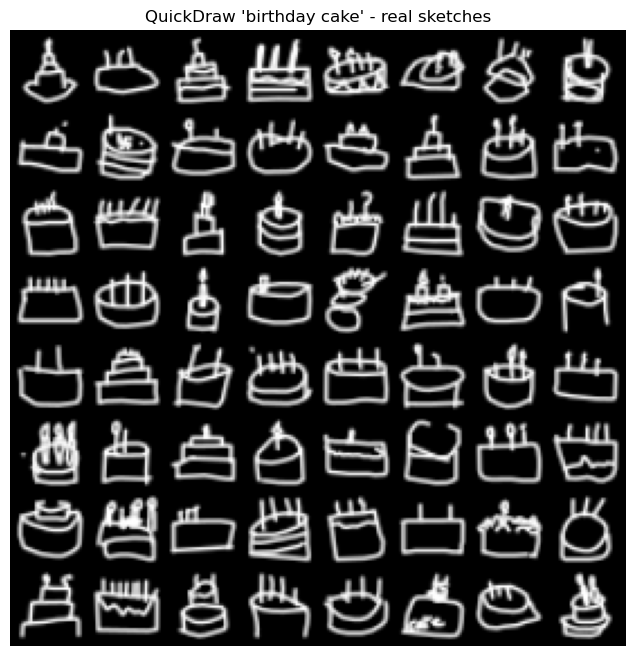

In [37]:
import urllib.request

QD_DIR = os.path.join(OUTPUT_DIR, "quickdraw")
os.makedirs(QD_DIR, exist_ok=True)


def fetch_quickdraw(category):
    """Download one QuickDraw numpy-bitmap category; returns an (N, 28, 28) uint8 array."""
    url = ("https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
           + category.replace(" ", "%20") + ".npy")
    local = os.path.join(QD_DIR, category.replace(" ", "_") + ".npy")
    if not os.path.exists(local):
        print("downloading QuickDraw:", category)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as resp, open(local, "wb") as fh:
            fh.write(resp.read())
    return np.load(local).reshape(-1, 28, 28)


cake_images = fetch_quickdraw("birthday cake")
print("birthday cake bitmaps:", cake_images.shape)
show_grid(images_to_tensor(cake_images[:64]), "QuickDraw 'birthday cake' - real sketches", "qd_cake_real.png")

## 2.3.2 - DCGAN model, data pipeline and training loop

The sketch generator and critic use the same transposed-/strided-convolution DCGAN design as the OCT model. Bitmaps are served through a custom `torch.utils.data.Dataset` (`SketchDataset`) that converts them to `[-1, 1]` tensors on the fly, and training reuses `ImageDCGANTrainer` with one-sided label smoothing.

In [38]:
class SketchGenerator(nn.Module):
    """DCGAN generator for 32x32 sketches (transposed-convolution upsampling)."""

    def __init__(self, latent=QD_LATENT, feats=64, channels=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent, feats * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feats * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feats * 4, feats * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feats * 2, feats, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats), nn.ReLU(True),
            nn.ConvTranspose2d(feats, channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.model(z.view(z.size(0), z.size(1), 1, 1))


class SketchCritic(nn.Module):
    """DCGAN discriminator for 32x32 sketches."""

    def __init__(self, feats=64, channels=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(channels, feats, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats, feats * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats * 2), nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats * 2, feats * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feats * 4), nn.LeakyReLU(0.2, True), nn.Dropout(0.25),
            nn.Conv2d(feats * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.model(x).view(x.size(0), 1)

In [39]:
class SketchDataset(torch.utils.data.Dataset):
    """Lazily converts uint8 QuickDraw bitmaps to [-1, 1] 32x32 tensors."""

    def __init__(self, uint8_images, size=32):
        self.images = uint8_images
        self.size = size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        tensor = images_to_tensor(self.images[idx:idx + 1], self.size)
        return (tensor[0],)


def make_sketch_loader(uint8_images, batch=128, cap=20000):
    """DataLoader built on the custom SketchDataset."""
    picks = uint8_images[np.random.permutation(len(uint8_images))[:cap]]
    return DataLoader(SketchDataset(picks), batch_size=batch, shuffle=True, drop_last=True)


def ink_coverage(uint8_images, sample=3000):
    """Mean normalised pixel intensity - a rough sketch-complexity proxy."""
    picks = np.random.permutation(len(uint8_images))[:sample]
    return float((uint8_images[picks].astype(np.float32) / 255.0).mean())

## 2.3.3 - Train on 'birthday cake' and evaluate

This trains the cake DCGAN for 45 epochs, plots the losses, and compares generated cakes with real ones both visually and by FID.

[qd_birthday_cake] epoch   1/45 | D 0.472 | G 5.205
[qd_birthday_cake] epoch   2/45 | D 0.542 | G 4.066
[qd_birthday_cake] epoch   3/45 | D 0.568 | G 2.868
[qd_birthday_cake] epoch   4/45 | D 0.824 | G 1.566
[qd_birthday_cake] epoch   5/45 | D 0.595 | G 3.570
[qd_birthday_cake] epoch   6/45 | D 0.648 | G 1.833
[qd_birthday_cake] epoch   7/45 | D 1.000 | G 1.041
[qd_birthday_cake] epoch   8/45 | D 0.607 | G 2.609
[qd_birthday_cake] epoch   9/45 | D 1.063 | G 2.338
[qd_birthday_cake] epoch  10/45 | D 0.729 | G 3.070
[qd_birthday_cake] epoch  11/45 | D 0.652 | G 2.009
[qd_birthday_cake] epoch  12/45 | D 0.686 | G 2.707
[qd_birthday_cake] epoch  13/45 | D 0.742 | G 3.210
[qd_birthday_cake] epoch  14/45 | D 0.670 | G 2.732
[qd_birthday_cake] epoch  15/45 | D 0.640 | G 2.356
[qd_birthday_cake] epoch  16/45 | D 0.657 | G 2.570
[qd_birthday_cake] epoch  17/45 | D 0.658 | G 2.249
[qd_birthday_cake] epoch  18/45 | D 0.710 | G 2.801
[qd_birthday_cake] epoch  19/45 | D 0.573 | G 2.790
[qd_birthday

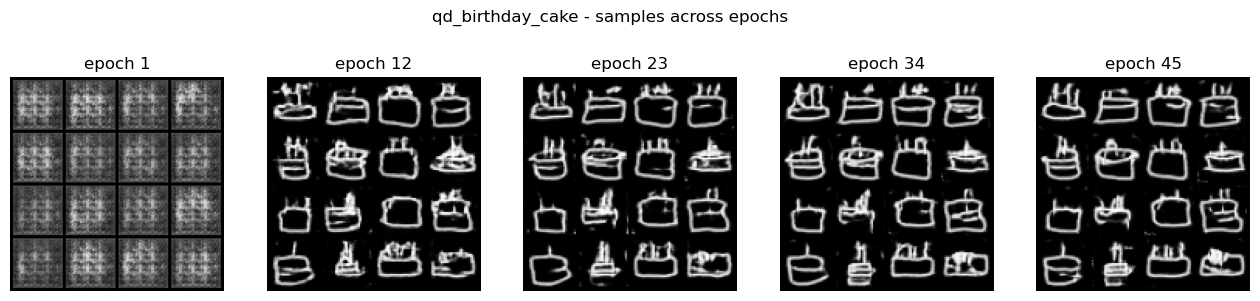

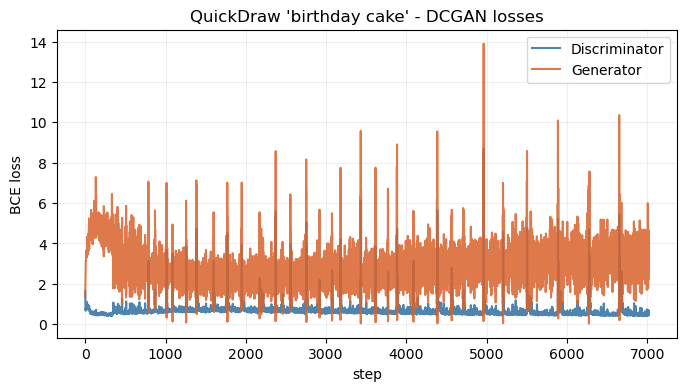

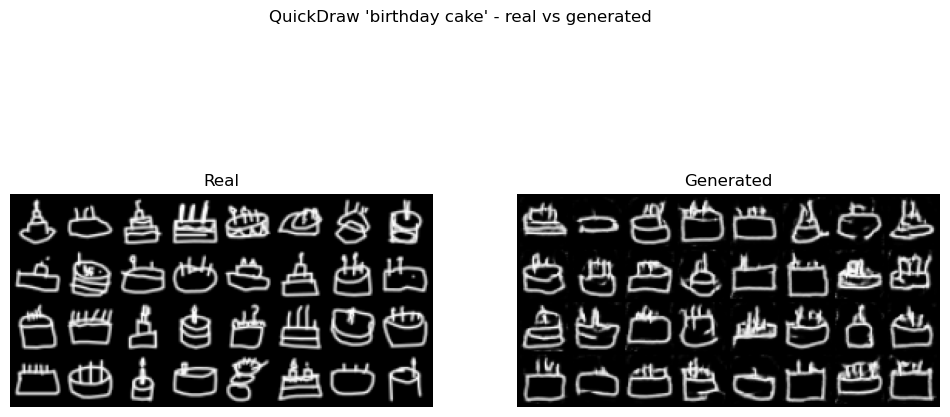

QuickDraw birthday cake: FID = 32.09


In [40]:
fix_torch_seeds()
cake_gen = SketchGenerator(); cake_gen.apply(init_dcgan_weights)
cake_critic = SketchCritic(); cake_critic.apply(init_dcgan_weights)
cake_trainer = ImageDCGANTrainer(cake_gen, cake_critic, QD_LATENT, "qd_birthday_cake")

cake_g_hist, cake_d_hist = cake_trainer.fit(make_sketch_loader(cake_images), QD_EPOCHS)
draw_loss_curves(cake_d_hist, cake_g_hist, "QuickDraw 'birthday cake' - DCGAN losses", "qd_cake_losses.png")

cake_fake = cake_trainer.generate(2000)
show_real_and_fake(images_to_tensor(cake_images[:32]), cake_fake[:32],
                   "QuickDraw 'birthday cake' - real vs generated", "qd_cake_real_vs_fake.png")
cake_fid = fid_scorer.score(cake_images, cake_fake, "QuickDraw birthday cake")

## 2.3 (extension) - Other categories and sketch complexity

The same DCGAN is trained on two more categories (cat and house), and their FID scores are placed next to an "ink density" measure of how busy each category's sketches are. The idea is to see whether denser, more detailed categories are harder to model.

downloading QuickDraw: cat
[qd_cat] epoch   1/45 | D 0.567 | G 3.966
[qd_cat] epoch   2/45 | D 0.602 | G 4.117
[qd_cat] epoch   3/45 | D 0.668 | G 2.371
[qd_cat] epoch   4/45 | D 0.648 | G 2.589
[qd_cat] epoch   5/45 | D 0.617 | G 3.319
[qd_cat] epoch   6/45 | D 0.694 | G 2.135
[qd_cat] epoch   7/45 | D 0.817 | G 3.246
[qd_cat] epoch   8/45 | D 0.829 | G 1.288
[qd_cat] epoch   9/45 | D 0.916 | G 1.717
[qd_cat] epoch  10/45 | D 0.798 | G 2.767
[qd_cat] epoch  11/45 | D 0.807 | G 1.486
[qd_cat] epoch  12/45 | D 0.773 | G 1.188
[qd_cat] epoch  13/45 | D 0.931 | G 3.686
[qd_cat] epoch  14/45 | D 0.754 | G 1.992
[qd_cat] epoch  15/45 | D 0.807 | G 3.163
[qd_cat] epoch  16/45 | D 1.453 | G 1.916
[qd_cat] epoch  17/45 | D 0.546 | G 3.446
[qd_cat] epoch  18/45 | D 0.650 | G 3.787
[qd_cat] epoch  19/45 | D 0.486 | G 2.503
[qd_cat] epoch  20/45 | D 0.495 | G 2.748
[qd_cat] epoch  21/45 | D 0.513 | G 2.826
[qd_cat] epoch  22/45 | D 0.593 | G 2.306
[qd_cat] epoch  23/45 | D 0.494 | G 4.221
[qd_cat

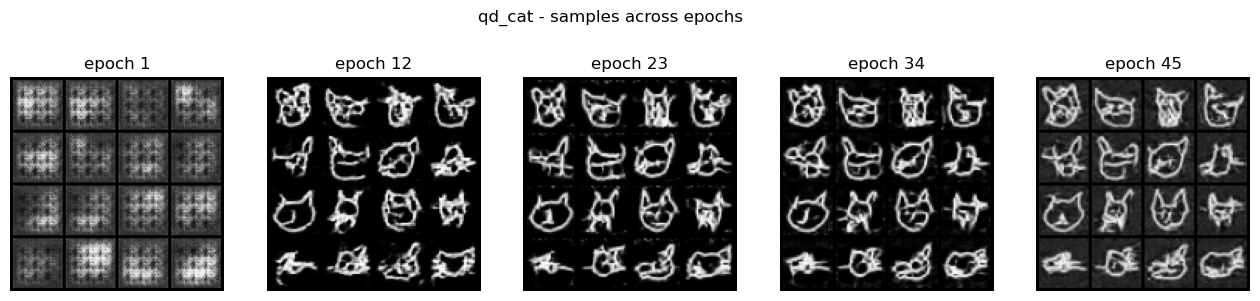

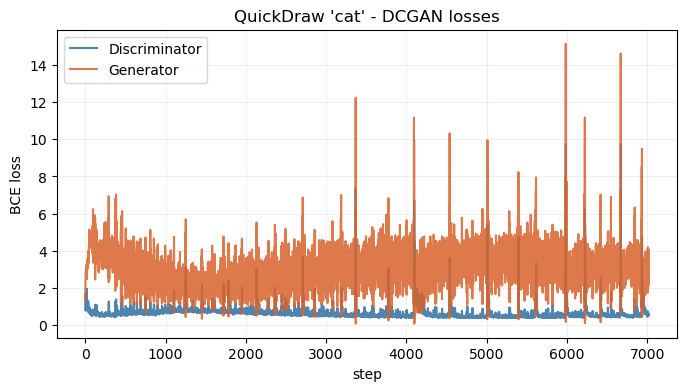

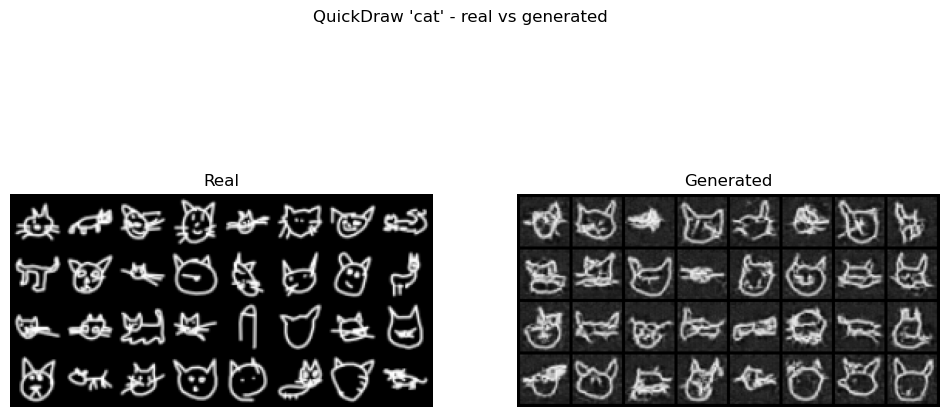

QuickDraw cat: FID = 79.44
downloading QuickDraw: house
[qd_house] epoch   1/45 | D 0.446 | G 5.044
[qd_house] epoch   2/45 | D 0.653 | G 2.563
[qd_house] epoch   3/45 | D 0.675 | G 2.523
[qd_house] epoch   4/45 | D 0.608 | G 2.910
[qd_house] epoch   5/45 | D 0.616 | G 2.279
[qd_house] epoch   6/45 | D 0.613 | G 2.505
[qd_house] epoch   7/45 | D 0.675 | G 3.130
[qd_house] epoch   8/45 | D 0.651 | G 2.412
[qd_house] epoch   9/45 | D 1.472 | G 0.291
[qd_house] epoch  10/45 | D 0.616 | G 1.947
[qd_house] epoch  11/45 | D 0.696 | G 2.428
[qd_house] epoch  12/45 | D 0.674 | G 2.848
[qd_house] epoch  13/45 | D 0.754 | G 1.749
[qd_house] epoch  14/45 | D 0.660 | G 2.672
[qd_house] epoch  15/45 | D 3.817 | G 2.358
[qd_house] epoch  16/45 | D 0.648 | G 2.357


In [ ]:
qd_fid = {"birthday cake": cake_fid}
qd_ink = {"birthday cake": ink_coverage(cake_images)}

for category in QD_EXTRA:
    imgs = fetch_quickdraw(category)
    qd_ink[category] = ink_coverage(imgs)
    fix_torch_seeds()
    gen = SketchGenerator(); gen.apply(init_dcgan_weights)
    critic = SketchCritic(); critic.apply(init_dcgan_weights)
    trainer = ImageDCGANTrainer(gen, critic, QD_LATENT, f"qd_{category}")
    g_hist, d_hist = trainer.fit(make_sketch_loader(imgs), QD_EPOCHS)
    draw_loss_curves(d_hist, g_hist, f"QuickDraw '{category}' - DCGAN losses", f"qd_{category}_losses.png")
    fake = trainer.generate(2000)
    show_real_and_fake(images_to_tensor(imgs[:32]), fake[:32],
                       f"QuickDraw '{category}' - real vs generated", f"qd_{category}_real_vs_fake.png")
    qd_fid[category] = fid_scorer.score(imgs, fake, f"QuickDraw {category}")

In [ ]:
names = list(qd_fid.keys())
fig, (ax_fid, ax_ink) = plt.subplots(1, 2, figsize=(12, 4))
ax_fid.bar(names, [qd_fid[n] for n in names], color="#2f6f9f")
ax_fid.set_title("FID by category (lower is better)"); ax_fid.tick_params(axis="x", rotation=20)
ax_ink.bar(names, [qd_ink[n] for n in names], color="#d9622b")
ax_ink.set_title("Ink-density complexity proxy"); ax_ink.tick_params(axis="x", rotation=20)
fig.suptitle("QuickDraw extension: FID vs ink-density complexity")
save_figure(fig, "qd_extension_summary.png"); plt.show()

print("QuickDraw category summary:")
for n in names:
    print(f"  {n:>14}: FID = {qd_fid[n]:.2f} | ink-density = {qd_ink[n]:.4f}")

## 2.3 reflection

**Cake.** `[Comment on whether the generated cakes are recognisable - a cake body with candle-like marks - and whether training stayed stable across the 45 epochs.]` FID = `[cake FID]`.

**Cat.** FID = `[cat FID]`. `[Cat sketches vary a lot in pose and detail, so they are usually the hardest of the three - say whether that held here.]`

**House.** FID = `[house FID]`.

**FID vs complexity.** Ink-density order was `[list the three ink-density values]` and the FID order was `[list the three FID values]`. `[State whether the sparsest category was actually the easiest by FID.]` In my runs ink density on its own does not predict FID well - how much the sketches vary within a category seems to matter more than how much ink is on the page, and a fixed-capacity DCGAN struggles most with the most varied category.

## Save all outputs to `set4_results/` and zip them

Every figure is written into `set4_results/` as it is produced. This last cell also sweeps up any stray figures left in the working directory, folds them into the same folder, and zips the lot as `set4_results.zip` so everything downloads together.

In [ ]:
import glob
import shutil

os.makedirs(OUTPUT_DIR, exist_ok=True)
# Gather any figures written to the working directory into the results folder.
for stray in glob.glob("*.png"):
    shutil.move(stray, os.path.join(OUTPUT_DIR, os.path.basename(stray)))

archive = shutil.make_archive("set4_results", "zip", OUTPUT_DIR)
print("Results folder:", os.path.abspath(OUTPUT_DIR))
print("Zipped archive:", os.path.abspath(archive))